# 08 · Reseñas — Silver, Gold y GEO Benchmarking

**Objetivo:** construir de extremo a extremo el pipeline de reseñas de La Roca (Google Maps + TripAdvisor): depuración y enriquecimiento (Silver), extracción de entidades y *Aspect-Based Sentiment Analysis* (ABSA), analítica de negocio orientada al dueño del restaurante (Gold) y un módulo de *Generative Engine Optimization* (GEO) que audita cómo posicionan los LLMs al restaurante frente a su competencia.

**Fuentes (bronze):**
- `data/bronze/resenia/googleresenia_0.csv` y `googleresenia_1.csv` — 803 reseñas de Google Maps ya pre-estructuradas (autor, tipo de comida, rango de precio, sentimiento, platos mencionados, aspectos positivos/negativos, respuesta del propietario).
- `data/bronze/resenia/tripadvisor_estructurado.csv` — 162 reseñas de TripAdvisor con el mismo tipo de estructura y fecha de escritura ya normalizada.
- `data/bronze/google_reviews_la_roca_parsed.csv` — muestra de 117 reseñas de Google con metadatos de motor (Local Guide, nº de reseñas/fotos del autor, reacciones) que se usa como **enriquecimiento** best-effort sobre las 803 anteriores.
- `data/bronze/resenia/*.docx` — texto crudo original de las reseñas (se documenta como procedencia, no se re-parsea: las reseñas ya llegan estructuradas en los CSV anteriores).
- `data/bronze/CARTA.xls` — carta real del restaurante, usada para **anclar** la extracción de platos (NER) a artículos que existen de verdad en el menú.

**Estructura del notebook:**
1. Capa Silver — limpieza, unificación de plataformas, NER y ABSA.
2. Capa Gold — KPIs de negocio y visual analytics para el dueño.
3. Módulo GEO — auditoría de visibilidad en LLMs (ChatGPT, Gemini, Perplexity…).
4. Ideas extra — detección de caídas de calidad, alertas de reseñas críticas sin responder y simulador de impacto en carta.

> **Nota metodológica:** no se dispone en el entorno de librerías de NLP pesadas (spaCy, transformers) ni de acceso a internet garantizado. El NER y el ABSA se implementan mediante diccionarios curados y anclados a los datos reales (grep sobre el corpus, cruce con la carta oficial) y reglas de sentimiento léxico transparentes — un enfoque explicable y 100% reproducible, apropiado para un TFM y sin dependencias nuevas.

## Sección 0 · Setup

Importamos librerías, aplicamos el tema visual del proyecto (`tfm_theme`) y definimos las rutas de datos siguiendo la convención Bronze → Silver → Gold ya usada en el resto de notebooks.

In [1]:
from __future__ import annotations

import json
import re
import sys
import unicodedata
import warnings
from dataclasses import dataclass
from pathlib import Path
from typing import Any, Literal

from dotenv import load_dotenv
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")
load_dotenv()  # lee GROQ_API_KEY / GOOGLE_API_KEY del .env de la raiz (Seccion 3, modulo GEO)
pd.set_option("display.max_colwidth", 120)

In [2]:
# ── Rutas del proyecto ────────────────────────────────────────────────────────
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent

# Añadir raíz y src/ al path para importar módulos propios
for p in [str(PROJECT_ROOT), str(PROJECT_ROOT / 'src')]:
    if p not in sys.path:
        sys.path.insert(0, p)

from tfm_io import read_menu
from tfm_theme import apply_theme, PALETTE, COLOR_PRIMARY, COLOR_SECONDARY, COLOR_ACCENT

apply_theme()

DATA_DIR      = PROJECT_ROOT / 'data'
BRONZE_DIR    = DATA_DIR / 'bronze'
RESENIA_DIR   = BRONZE_DIR / 'resenia'
SILVER_SNAP   = DATA_DIR / 'silver' / 'snapshots'
GOLD_DIR      = DATA_DIR / 'gold'
FIGURES_DIR   = PROJECT_ROOT / 'results' / 'figures' / 'reviews_overview'

for directory in (SILVER_SNAP, GOLD_DIR, FIGURES_DIR):
    directory.mkdir(parents=True, exist_ok=True)

print(f'Project root   : {PROJECT_ROOT}')
print(f'Reseñas bronze : {RESENIA_DIR}')
print(f'Silver snaps   : {SILVER_SNAP}')
print(f'Gold dir       : {GOLD_DIR}')

Project root   : C:\Users\CandelaGB\Desktop\TFM anita\TFM-Hosteleria-AI
Reseñas bronze : C:\Users\CandelaGB\Desktop\TFM anita\TFM-Hosteleria-AI\data\bronze\resenia
Silver snaps   : C:\Users\CandelaGB\Desktop\TFM anita\TFM-Hosteleria-AI\data\silver\snapshots
Gold dir       : C:\Users\CandelaGB\Desktop\TFM anita\TFM-Hosteleria-AI\data\gold


# SECCIÓN 1 · CAPA SILVER (limpieza, ABSA y normalización)

## 1.1 Carga de fuentes bronze

Cargamos los cuatro ficheros de origen. `load_bronze_sources` falla explícitamente (`FileNotFoundError`) si falta alguno, en vez de continuar con un pipeline a medias — preferible detectar el problema aquí antes que producir un Silver incompleto silenciosamente.

In [3]:
def load_bronze_sources(resenia_dir: Path, bronze_dir: Path) -> dict[str, pd.DataFrame]:
    '''
    Load the four raw review sources into memory.

    Parameters
    ----------
    resenia_dir : Path
        Directory containing the review CSV exports (data/bronze/resenia).
    bronze_dir : Path
        Root bronze directory (data/bronze), used for the engagement sample.

    Returns
    -------
    dict[str, pandas.DataFrame]
        One entry per source: 'google_0', 'google_1', 'tripadvisor',
        'google_engagement'.

    Raises
    ------
    FileNotFoundError
        If any of the expected files is missing.
    '''
    files: dict[str, Path] = {
        'google_0': resenia_dir / 'googleresenia_0.csv',
        'google_1': resenia_dir / 'googleresenia_1.csv',
        'tripadvisor': resenia_dir / 'tripadvisor_estructurado.csv',
        'google_engagement': bronze_dir / 'google_reviews_la_roca_parsed.csv',
    }

    missing = [str(path) for path in files.values() if not path.exists()]
    if missing:
        raise FileNotFoundError(
            'Faltan ficheros de origen esperados:\n' + '\n'.join(missing)
        )

    return {name: pd.read_csv(path, encoding='utf-8') for name, path in files.items()}


bronze_sources = load_bronze_sources(RESENIA_DIR, BRONZE_DIR)

for name, frame in bronze_sources.items():
    print(f'{name:<20} shape={frame.shape}')

google_0             shape=(273, 12)
google_1             shape=(530, 12)
tripadvisor          shape=(162, 14)
google_engagement    shape=(117, 16)


## 1.2 Utilidades de texto y parseo de campos crudos

Funciones puras y tipadas, reutilizadas por todo el notebook:
- `strip_accents` / `normalize_text` — normalización robusta para comparar texto en español (minúsculas, sin tildes, sin espacios repetidos).
- `parse_price_range` — convierte `"30-40 €"` en `(30.0, 40.0)`.
- `parse_relative_spanish_date` — convierte `"Hace 4 meses"` en una fecha absoluta a partir de una fecha de referencia.
- `parse_profile_detail` — extrae de `"Local Guide · 171 reseñas · 745 fotos"` si el autor es Local Guide y sus contadores.
- `split_dish_list` — separa el campo `Platos_Mencionados` (cadena separada por comas) en una lista.

In [4]:
def strip_accents(text: str) -> str:
    '''Remove diacritics from a string (á -> a, ñ -> n, ...).'''
    normalized = unicodedata.normalize('NFKD', text)
    return ''.join(c for c in normalized if not unicodedata.combining(c))


def normalize_text(value: Any) -> str:
    '''Lowercase, accent-strip and collapse whitespace for robust text matching.'''
    if pd.isna(value):
        return ''
    text = strip_accents(str(value))
    return re.sub(r'\s+', ' ', text).strip().lower()


# ── Precio ────────────────────────────────────────────────────────────────────
_PRICE_RANGE_RE = re.compile(r'(\d+)\s*-\s*(\d+)')
_PRICE_MORE_THAN_RE = re.compile(r'm[aá]s de\s*(\d+)', re.IGNORECASE)


def parse_price_range(value: Any) -> tuple[float | None, float | None]:
    '''Parse a price-range string such as "30-40 €" or "Más de 100 €".'''
    if pd.isna(value):
        return (None, None)
    text = str(value)
    match = _PRICE_RANGE_RE.search(text)
    if match:
        return (float(match.group(1)), float(match.group(2)))
    match_more = _PRICE_MORE_THAN_RE.search(strip_accents(text))
    if match_more:
        low = float(match_more.group(1))
        return (low, low * 1.25)  # banda abierta: se asume +25% como techo estimado
    return (None, None)


# ── Fechas relativas en español ──────────────────────────────────────────────
_UNIT_TO_DAYS = {
    'dia': 1, 'dias': 1,
    'semana': 7, 'semanas': 7,
    'mes': 30, 'meses': 30,
    'ano': 365, 'anos': 365,
}
_NUMBER_WORDS = {'un': 1, 'una': 1}
_RELATIVE_DATE_RE = re.compile(
    r'hace\s+(un|una|\d+)\s+(dia|dias|semana|semanas|mes|meses|ano|anos)'
)


def parse_relative_spanish_date(value: Any, reference_date: pd.Timestamp) -> pd.Timestamp:
    '''
    Convert a Google-style relative date ("Hace 4 meses") into an absolute
    timestamp anchored on `reference_date`.
    el dia que se sacaron los datos fue el 21-08-2026
    Returns pandas.NaT if the text does not match the expected pattern.
    '''
    if pd.isna(value):
        return pd.NaT
    text = strip_accents(str(value)).lower().strip()
    match = _RELATIVE_DATE_RE.search(text)
    if not match:
        return pd.NaT
    quantity_raw, unit = match.groups()
    quantity = _NUMBER_WORDS.get(quantity_raw)
    if quantity is None:
        try:
            quantity = int(quantity_raw)
        except ValueError:
            return pd.NaT
    return reference_date - pd.Timedelta(days=quantity * _UNIT_TO_DAYS[unit])


# ── Perfil de autor (Google) ─────────────────────────────────────────────────
_PROFILE_RE = re.compile(
    r'(?:(Local Guide)\s*[·\-]\s*)?(\d+)\s*rese[nñ]as(?:\s*[·\-]\s*(\d+)\s*fotos)?',
    re.IGNORECASE,
)


def parse_profile_detail(value: Any) -> tuple[bool, float | None, float | None]:
    '''Parse "Local Guide · 171 reseñas · 745 fotos" into (is_guide, n_reviews, n_photos).'''
    if pd.isna(value):
        return (False, None, None)
    match = _PROFILE_RE.search(strip_accents(str(value)))
    if not match:
        return (False, None, None)
    is_guide, n_reviews, n_photos = match.groups()
    return (
        bool(is_guide),
        float(n_reviews) if n_reviews else None,
        float(n_photos) if n_photos else None,
    )


def split_dish_list(value: Any) -> list[str]:
    '''Split the comma-separated "Platos_Mencionados" field into a clean list.'''
    if pd.isna(value):
        return []
    text = str(value).strip()
    if not text:
        return []
    return [part.strip() for part in text.split(',') if part.strip()]


# Comprobaciones rápidas (no exhaustivas, documentan el contrato de cada función)
assert parse_price_range('30-40 €') == (30.0, 40.0)
assert parse_price_range('Más de 100 €') == (100.0, 125.0)
assert parse_profile_detail('Local Guide · 171 reseñas · 745 fotos') == (True, 171.0, 745.0)
assert split_dish_list('Torreznos, Pulpo, Tarta árabe') == ['Torreznos', 'Pulpo', 'Tarta árabe']
print('Utilidades de parseo OK')

Utilidades de parseo OK


## 1.3 Normalización por plataforma y unificación de esquema

Google y TripAdvisor llegan con columnas distintas (`Perfil_Detalle` vs `Ubicacion`/`Contribuciones`, `Tipo_Comida` vs `Tipo_Visita`, fecha relativa vs fecha absoluta ya parseada...). Cada plataforma tiene su propia función de normalización; ambas devuelven el mismo esquema unificado para poder concatenar.

**Fecha de referencia para Google:** los datos de TripAdvisor ya traen `Fecha_Escrita` en ISO (hasta 2026-03-20), así que asumimos que los datos de Google corresponden a la misma ventana temporal y fijamos `REFERENCE_DATE = 2026-03-01` para traducir sus fechas relativas ("Hace 4 meses") a fechas absolutas. **Es una asunción explícita**: si se conoce la fecha exacta de captura de los datos de Google, debe sustituirse aquí.

In [5]:
REFERENCE_DATE = pd.Timestamp('2026-08-21')

_OWNER_RESPONDED_RE = re.compile(r'\bs[ií]\b', re.IGNORECASE)


def normalize_google_reviews(google_0: pd.DataFrame, google_1: pd.DataFrame) -> pd.DataFrame:
    '''
    Standardize the two Google-review batches into the unified review schema.

    Parameters
    ----------
    google_0, google_1 : pandas.DataFrame
        Raw Google review batches (ID ranges 1-273 and 274-803, no overlap).

    Returns
    -------
    pandas.DataFrame
        Unified schema, one row per review.
    '''
    data = pd.concat([google_0, google_1], ignore_index=True)
    profile = data['Perfil_Detalle'].map(parse_profile_detail)
    price = data['Rango_Precio'].map(parse_price_range)

    out = pd.DataFrame({
        'platform': 'google',
        'source_review_id': data['ID'].astype(str),
        'author': data['Usuario'].astype('string').str.strip(),
        'is_local_guide': [p[0] for p in profile],
        'author_n_reviews': [p[1] for p in profile],
        'author_n_photos': [p[2] for p in profile],
        'review_date_relative': data['Tiempo_Aproximado'],
        'review_date': data['Tiempo_Aproximado'].map(
            lambda v: parse_relative_spanish_date(v, REFERENCE_DATE)
        ),
        'visit_type': data['Tipo_Comida'],
        'price_min': [p[0] for p in price],
        'price_max': [p[1] for p in price],
        'sentiment_source': data['Sentimiento'],
        'dishes_raw': data['Platos_Mencionados'].map(split_dish_list),
        'positive_aspects_text': data['Aspectos_Positivos'].astype('string'),
        'negative_aspects_text': data['Aspectos_Negativos'].astype('string'),
        'owner_responded': data['Respuesta_Propietario'].astype(str).str.contains(
            _OWNER_RESPONDED_RE
        ),
        'review_text': data['Texto_Resena'].astype('string'),
    })
    out['price_mid'] = out[['price_min', 'price_max']].mean(axis=1)
    return out


def normalize_tripadvisor_reviews(tripadvisor: pd.DataFrame) -> pd.DataFrame:
    '''
    Standardize the TripAdvisor export into the unified review schema.

    TripAdvisor already provides an absolute `Fecha_Escrita` (ISO date) and no
    price-range field, so `price_min`/`price_max` stay null for this platform.
    '''
    out = pd.DataFrame({
        'platform': 'tripadvisor',
        'source_review_id': tripadvisor['ID'].astype(str),
        'author': tripadvisor['Usuario'].astype('string').str.strip(),
        'is_local_guide': False,
        'author_n_reviews': tripadvisor['Contribuciones'],
        'author_n_photos': pd.NA,
        'review_date_relative': tripadvisor['Fecha_Visita'],
        'review_date': pd.to_datetime(tripadvisor['Fecha_Escrita'], errors='coerce'),
        'visit_type': tripadvisor['Tipo_Visita'],
        'price_min': pd.NA,
        'price_max': pd.NA,
        'sentiment_source': tripadvisor['Sentimiento'],
        'dishes_raw': tripadvisor['Platos_Mencionados'].map(split_dish_list),
        'positive_aspects_text': tripadvisor['Aspectos_Positivos'].astype('string'),
        'negative_aspects_text': tripadvisor['Aspectos_Negativos'].astype('string'),
        'owner_responded': tripadvisor['Respuesta_Restaurante'].astype(str).str.contains(
            _OWNER_RESPONDED_RE
        ),
        'review_text': tripadvisor['Texto_Resena'].astype('string'),
    })
    out['price_mid'] = pd.NA
    return out

In [6]:
def enrich_with_engagement(reviews: pd.DataFrame, engagement: pd.DataFrame) -> pd.DataFrame:
    '''
    Best-effort enrichment of Google reviews with engagement metadata.

    `google_reviews_la_roca_parsed.csv` is a smaller, independently-collected
    sample (117 rows) that overlaps with the first Google batch. Since there is
    no shared ID between sources, reviews are matched on a fuzzy key built from
    the normalized author name plus the first 30 characters of the normalized
    review text — verified manually to match ~97% of the engagement sample.
    Unmatched reviews simply keep null engagement fields.

    Parameters
    ----------
    reviews : pandas.DataFrame
        Unified review table (output of normalize_google_reviews / _tripadvisor).
    engagement : pandas.DataFrame
        Raw `google_reviews_la_roca_parsed.csv` contents.

    Returns
    -------
    pandas.DataFrame
        `reviews` with `is_local_guide` / `author_n_reviews` / `author_n_photos`
        filled where a match exists, plus new columns `reacciones_total`,
        `comio_alli`, `editado`.
    '''
    eng = engagement.copy()
    eng['match_key'] = (
        eng['autor'].map(normalize_text) + '||'
        + eng['texto'].map(normalize_text).str.slice(0, 30)
    )
    eng_cols = eng[[
        'match_key', 'es_local_guide', 'n_resenas_autor', 'n_fotos_autor',
        'reacciones_total', 'comio_alli', 'editado',
    ]].drop_duplicates('match_key')

    out = reviews.copy()
    out['match_key'] = (
        out['author'].map(normalize_text) + '||'
        + out['review_text'].map(normalize_text).str.slice(0, 30)
    )
    merged = out.merge(eng_cols, on='match_key', how='left')

    merged['is_local_guide'] = merged['is_local_guide'].where(
        merged['es_local_guide'].isna(), merged['es_local_guide']
    )
    merged['author_n_reviews'] = merged['author_n_reviews'].where(
        merged['n_resenas_autor'].isna(), merged['n_resenas_autor']
    )
    merged['author_n_photos'] = merged['author_n_photos'].where(
        merged['n_fotos_autor'].isna(), merged['n_fotos_autor']
    )

    return merged.drop(columns=['es_local_guide', 'n_resenas_autor', 'n_fotos_autor', 'match_key'])


google_unified = normalize_google_reviews(bronze_sources['google_0'], bronze_sources['google_1'])
tripadvisor_unified = normalize_tripadvisor_reviews(bronze_sources['tripadvisor'])

reviews_unified = pd.concat([google_unified, tripadvisor_unified], ignore_index=True)
reviews_unified = enrich_with_engagement(reviews_unified, bronze_sources['google_engagement'])
reviews_unified['review_id'] = (
    reviews_unified['platform'].str.slice(0, 2) + '_' + reviews_unified['source_review_id']
)

print(f'Reseñas unificadas: {len(reviews_unified)}')
print(reviews_unified['platform'].value_counts())
print(f"\nEngagement enriquecido (reacciones_total no nulo): "
      f"{reviews_unified['reacciones_total'].notna().sum()} filas")
reviews_unified.head(3)

Reseñas unificadas: 965
platform
google         803
tripadvisor    162
Name: count, dtype: int64

Engagement enriquecido (reacciones_total no nulo): 114 filas


,platform,source_review_id,author,is_local_guide,author_n_reviews,author_n_photos,review_date_relative,review_date,visit_type,price_min,...,dishes_raw,positive_aspects_text,negative_aspects_text,owner_responded,review_text,price_mid,reacciones_total,comio_alli,editado,review_id
0,google,1,Jorge Sancerni,True,171.0,745.0,Hace 1 mes,2026-07-22,Cena,40.0,...,"[Sam de gamba, Ravioli de rabo, Bombones de Wagyu, Tartar de atún]","Todo muy rico, plan perfecto para ir en pareja o grupos",<NA>,False,"Repetiremos sin duda. Hemos ido a cenar en pareja aunque coincidimos con grupos de amigos y familia. Sam de gamba, R...",45.0,1.0,False,False,go_1
1,google,2,Rosa Visconti,True,115.0,355.0,Hace 4 meses,2026-04-23,Comida,40.0,...,"[Tartar de atún rojo, Bikini de pesto, Torreznos con patatas revolconas, Croquetas de jamón ibérico, Albóndigas de w...",Comida buena y servicio rápido a la mesa; sobresaliente el tartar y el bikini de pesto,Croquetas decepcionantes por estar súper saladas,False,Estaba todo realmente bueno y llegó rápido a la mesa. Destacaría el tartar de atún y el bikini de pesto. Me decepcio...,45.0,0.0,False,False,go_2
2,google,3,gonzalo martin,True,436.0,1207.0,Hace 5 meses,2026-03-24,Cena,30.0,...,[],"Trato excelente del personal, buen sitio para grupos o familia",<NA>,False,"Buen restaurante en pozuelo para comer o cenar con amigos o familia, siendo el trato del personal excelente.",35.0,0.0,False,False,go_3


% de nulos por columna (solo columnas con nulos):
                       pct_nulos
reacciones_total            88.2
editado                     88.2
comio_alli                  88.2
price_max                   70.7
price_mid                   70.7
price_min                   70.7
negative_aspects_text       68.7
author_n_photos             55.6
visit_type                  53.2
positive_aspects_text        7.9
author_n_reviews             3.9

Reseñas duplicadas (mismo autor + mismo texto): 0
Total tras deduplicar: 965


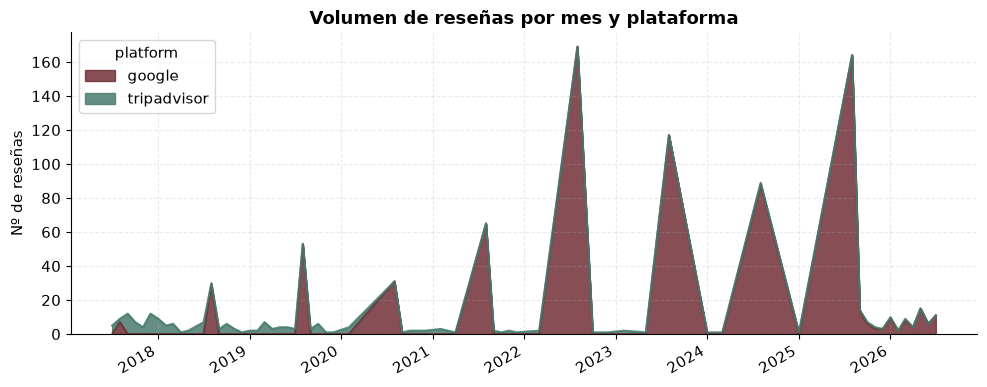

In [7]:
# ── Calidad de datos: nulos, duplicados y cobertura temporal ──────────────────
missing_report = (
    reviews_unified.isna().mean().mul(100).round(1).rename('pct_nulos')
    .to_frame().query('pct_nulos > 0').sort_values('pct_nulos', ascending=False)
)
print('% de nulos por columna (solo columnas con nulos):')
print(missing_report)

n_duplicated = reviews_unified.duplicated(subset=['author', 'review_text']).sum()
print(f'\nReseñas duplicadas (mismo autor + mismo texto): {n_duplicated}')

reviews_unified = reviews_unified.drop_duplicates(subset=['author', 'review_text']).reset_index(drop=True)
print(f'Total tras deduplicar: {len(reviews_unified)}')

fig, ax = plt.subplots(figsize=(10, 4))
monthly_counts = (
    reviews_unified.dropna(subset=['review_date'])
    .assign(month=lambda d: d['review_date'].dt.to_period('M').dt.to_timestamp())
    .groupby(['month', 'platform']).size().unstack(fill_value=0)
)
monthly_counts.plot(kind='area', stacked=True, ax=ax, alpha=0.85, color=[COLOR_PRIMARY, COLOR_SECONDARY])
ax.set_title('Volumen de reseñas por mes y plataforma')
ax.set_xlabel('')
ax.set_ylabel('Nº de reseñas')
plt.tight_layout()
plt.savefig(FIGURES_DIR / '01_volumen_resenas_mensual.png')
plt.show()

## 1.4 Extracción de entidades (NER) anclada a datos reales

En vez de intentar reconstruir un NER genérico desde cero (frágil sin spaCy/transformers), anclamos cada tipo de entidad a evidencia real del propio proyecto:

- **Platos/bebidas** → el campo `Platos_Mencionados` ya aporta menciones por reseña (933 menciones, 472 cadenas distintas por variación de redacción). Se construye un **diccionario de canonicalización** curado a partir del análisis de frecuencias (los ~45 platos más mencionados, agrupando variantes y erratas — p. ej. "ravioli" / "raviolis" / "ravioli de rabo" / "ravioli de rabo de toro" → *Ravioli de Rabo de Toro*) y se excluyen términos genéricos sin valor analítico ("tapas", "postres", "vino"...). Adicionalmente se cruza cada plato canónico contra la **carta real** (`CARTA.xls`, 405 artículos) para marcar si sigue vigente en el menú actual.
- **Personal de sala** → diccionario de alias construido inspeccionando manualmente las ventanas de texto alrededor de palabras clave de servicio (`camarero`, `atendió`, `encargado`, `chef`...) sobre el corpus completo. Se confirmaron 12 nombres reales (Ney/Neim, Óscar, Jessica, Alejandro, Otman, Doris, Valeria, Candela, Manu, Nilmar, Valentín y el chef Alberto Molinero).
- **Atributos del local** → diccionario de palabras clave de dominio (terraza, ruido, tiempos de espera, precio, ración/tamaño, ambiente, reservas/aforo, limpieza).

In [8]:
# ── Diccionario de canonicalización de platos (curado por frecuencia real) ────
CANONICAL_DISH_MAP: dict[str, str] = {
    'croquetas': 'Croquetas', 'croquetas de jamon': 'Croquetas',
    'tortilla de betanzos': 'Tortilla de Betanzos', 'tortilla': 'Tortilla de Betanzos',
    'alcachofas': 'Alcachofas a la Brasa',
    'bombones de foie': 'Bombones de Foie', 'bombones de foie y membrillo': 'Bombones de Foie',
    'ravioli de rabo de toro': 'Ravioli de Rabo de Toro', 'ravioli de rabo': 'Ravioli de Rabo de Toro',
    'ravioli': 'Ravioli de Rabo de Toro', 'raviolis': 'Ravioli de Rabo de Toro',
    'hamburguesa': 'Hamburguesa',
    'kimuchi': 'Kimuchi de Marisco', 'kimuchi de marisco': 'Kimuchi de Marisco',
    'kimuchi de mariscos': 'Kimuchi de Marisco',
    'tartar de atun': 'Tartar de Atún', 'tartar': 'Tartar de Atún',
    'tratar de atun rojo': 'Tartar de Atún', 'tartar de atun rojo': 'Tartar de Atún',
    'torreznos': 'Torreznos con Revolconas', 'torreznos con patatas revolconas': 'Torreznos con Revolconas',
    'torrija': 'Torrija', 'torrija con helado de violeta': 'Torrija',
    'zamburinas': 'Zamburiñas',
    'ensaladilla': 'Ensaladilla',
    'patatas bravas': 'Bravas', 'bravas': 'Bravas',
    'pulpo a la brasa': 'Pulpo a la Brasa', 'pulpo': 'Pulpo a la Brasa',
    'tarta de queso': 'Tarta de Queso',
    'sam de gambas': 'Sam de Gambas', 'sam de gamba': 'Sam de Gambas',
    'tarta arabe': 'Tarta Árabe',
    'mejillones a la brasa': 'Mejillones a la Brasa',
    'callos': 'Callos',
    'arroz meloso': 'Arroz Meloso', 'arroz meloso con solomillo': 'Arroz Meloso',
    'chuleton matizado': 'Chuletón Matizado',
    'fideua': 'Fideuá',
    'chipirones': 'Chipirones', 'chipirones a la plancha': 'Chipirones',
    'salmorejo': 'Salmorejo',
    'vieira': 'Vieira',
    'mollete de cochinita pibil': 'Mollete de Cochinita Pibil',
    'empanadillas criollas': 'Empanadillas Criollas', 'empanadilla criolla': 'Empanadillas Criollas',
    'tuetano a la brasa': 'Tuétano a la Brasa',
    'chuletillas': 'Chuletillas',
    'pan bao': 'Bao', 'bao de cochinita pibil': 'Bao de Cochinita Pibil',
}

# Menciones frecuentes pero sin valor analítico a nivel de plato individual.
GENERIC_DISH_TERMS: set[str] = {
    'postres', 'tapas', 'cerveza', 'tapas de autor', 'raciones', 'vinos', 'vino',
    'platos de autor', 'platos fuera de carta', 'tapas variadas', 'platos de carta',
    'platos recomendados', 'tapas para compartir', 'carne', 'tapas y raciones',
    'platos para compartir', 'platos creativos', 'tapas frias y calientes',
    'carta de vinos', 'vinos seleccionados', 'agua del grifo', 'menu', 'plato del dia',
    'menu del dia', 'postres caseros', 'tapas elaboradas', 'canas', 'platos de temporada',
    'platos de mercado', 'platos elaborados', 'pan', 'chupitos',
}


def canonicalize_dish(raw_dish: str) -> str | None:
    '''Map a raw dish mention to its canonical name, or None if not curated.'''
    key = normalize_text(raw_dish)
    return CANONICAL_DISH_MAP.get(key)


# ── Cruce con la carta real (CARTA.xls) ────────────────────────────────────────
try:
    menu = read_menu(str(BRONZE_DIR / 'CARTA.xls'))
    menu_norm_names = set(menu['article_name'].map(normalize_text))
except (FileNotFoundError, ImportError) as exc:
    warnings.warn(f'No se pudo cargar la carta real ({exc}); en_carta_actual quedará como None.')
    menu, menu_norm_names = pd.DataFrame(), set()


def is_in_current_menu(canonical_dish: str) -> bool | None:
    '''
    Best-effort check of whether a canonical dish is still on the real menu.

    Uses token-overlap against the normalized menu article names: a dish is
    considered present if at least two significant words of its name appear
    together in some menu article name.
    '''
    if not menu_norm_names:
        return None
    dish_tokens = [t for t in normalize_text(canonical_dish).split() if len(t) > 3]
    if not dish_tokens:
        return None
    for article_name in menu_norm_names:
        hits = sum(1 for t in dish_tokens if t in article_name)
        if hits >= min(2, len(dish_tokens)):
            return True
    return False


dish_menu_status = {
    dish: is_in_current_menu(dish) for dish in sorted(set(CANONICAL_DISH_MAP.values()))
}
print(f'Carta real cargada: {len(menu)} artículos')
print(f"Platos canónicos aún vigentes en carta: "
      f"{sum(1 for v in dish_menu_status.values() if v)} / {len(dish_menu_status)}")

Carta real cargada: 405 artículos
Platos canónicos aún vigentes en carta: 27 / 31


In [9]:
# ── Diccionario de personal de sala (alias validados manualmente sobre el corpus) ─
STAFF_ALIASES: dict[str, list[str]] = {
    'Ney': ['ney', 'neim', 'nein'],
    'Óscar': ['oscar'],
    'Jessica': ['jessica'],
    'Alejandro': ['alejandro'],
    'Otman': ['otman'],
    'Doris': ['doris'],
    'Valeria': ['valeria'],
    'Candela': ['candela'],
    'Manu': ['manu'],
    'Nilmar': ['nilmar'],
    'Valentín': ['valentin'],
    'Alberto Molinero (Chef)': ['molinero'],
}
_STAFF_PATTERNS: dict[str, re.Pattern] = {
    name: re.compile(r'\b(' + '|'.join(re.escape(a) for a in aliases) + r')\b')
    for name, aliases in STAFF_ALIASES.items()
}


def extract_staff(text: str) -> list[str]:
    '''Detect mentions of known staff members in a review text.'''
    norm = strip_accents(str(text)).lower()
    return [name for name, pattern in _STAFF_PATTERNS.items() if pattern.search(norm)]


# ── Diccionario de atributos del local ────────────────────────────────────────
ATTRIBUTE_KEYWORDS: dict[str, list[str]] = {
    'Terraza': ['terraza'],
    'Ruido/Ambiente sonoro': ['ruido', 'ruidoso', 'musica alta'],
    'Tiempos de espera': ['espera', 'tardo', 'tardaron', 'rapido', 'rapidez', 'lento', 'lentitud'],
    'Precio': ['precio', 'caro', 'carisima', 'carisimo', 'barato', 'calidad precio'],
    'Ración/Tamaño': ['racion', 'raciones', 'cantidad', 'tamano', 'escaso', 'escasa', 'pequenas', 'pequenos'],
    'Ambiente/Decoración': ['ambiente', 'decoracion', 'acogedor'],
    'Reservas/Aforo': ['reserva', 'reservar', 'lleno', 'se llena', 'aforo'],
    'Limpieza': ['limpio', 'limpieza', 'sucio', 'sucios'],
}
_ATTRIBUTE_PATTERNS: dict[str, re.Pattern] = {
    name: re.compile(r'\b(' + '|'.join(re.escape(k) for k in kws) + r')')
    for name, kws in ATTRIBUTE_KEYWORDS.items()
}


def extract_attributes(text: str) -> list[str]:
    '''Detect mentions of known local attributes in a review text.'''
    norm = strip_accents(str(text)).lower()
    return [name for name, pattern in _ATTRIBUTE_PATTERNS.items() if pattern.search(norm)]


# ── Aplicar extracción a todo el corpus ────────────────────────────────────────
reviews_unified['dishes_detected'] = reviews_unified['dishes_raw'].map(
    lambda dishes: [c for d in dishes if (c := canonicalize_dish(d)) is not None]
)
reviews_unified['staff_detected'] = reviews_unified['review_text'].map(extract_staff)
reviews_unified['attributes_detected'] = reviews_unified['review_text'].map(extract_attributes)

print('Reseñas con al menos un plato canónico detectado:',
      (reviews_unified['dishes_detected'].str.len() > 0).sum())
print('Reseñas con al menos un miembro del personal mencionado:',
      (reviews_unified['staff_detected'].str.len() > 0).sum())
print('Reseñas con al menos un atributo del local detectado:',
      (reviews_unified['attributes_detected'].str.len() > 0).sum())

Reseñas con al menos un plato canónico detectado: 161
Reseñas con al menos un miembro del personal mencionado: 85
Reseñas con al menos un atributo del local detectado: 383


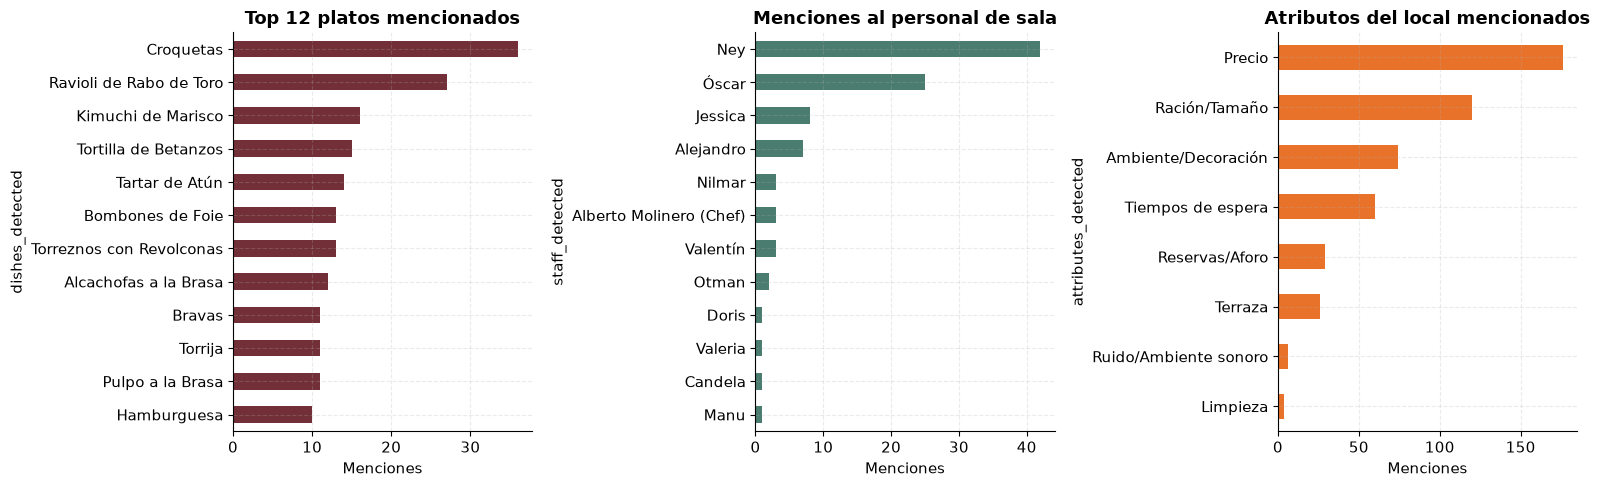

In [10]:
# ── Frecuencias de entidades detectadas ────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

dish_freq = reviews_unified['dishes_detected'].explode().value_counts().head(12)
dish_freq.sort_values().plot(kind='barh', ax=axes[0], color=COLOR_PRIMARY)
axes[0].set_title('Top 12 platos mencionados')
axes[0].set_xlabel('Menciones')

staff_freq = reviews_unified['staff_detected'].explode().value_counts()
staff_freq.sort_values().plot(kind='barh', ax=axes[1], color=COLOR_SECONDARY)
axes[1].set_title('Menciones al personal de sala')
axes[1].set_xlabel('Menciones')

attr_freq = reviews_unified['attributes_detected'].explode().value_counts()
attr_freq.sort_values().plot(kind='barh', ax=axes[2], color=COLOR_ACCENT)
axes[2].set_title('Atributos del local mencionados')
axes[2].set_xlabel('Menciones')

plt.tight_layout()
plt.savefig(FIGURES_DIR / '02_frecuencia_entidades.png')
plt.show()

## 1.5 Aspect-Based Sentiment Analysis (ABSA)

Para cada entidad detectada (plato, personal, atributo) calculamos un sentimiento específico, no el sentimiento global de la reseña. El método combina dos señales:

1. **Score léxico de la cláusula** — se localiza la cláusula (fragmento entre puntos/`;`/conectores adversativos) donde aparece la entidad y se puntúa con un lexicón de sentimiento en español orientado a restauración (positivos: *rico, exquisito, atento*...; negativos: *soso, saladas, escaso, lento*...), con manejo de negación (`no`, `nunca`, `sin`...) e intensificadores (`muy`, `super`...). Si la entidad no aparece literalmente en el texto (paráfrasis), se usa la reseña completa como fallback.
2. **Prior estructurado** — si la entidad aparece dentro de `Aspectos_Negativos` se aplica un sesgo negativo (-0.5); si aparece en `Aspectos_Positivos`, positivo (+0.5); si no aparece en ninguno, se usa el `Sentimiento` global de la reseña como prior débil.

El score final es `0.7 · score_léxico + 0.3 · prior`, acotado a `[-1, 1]`. Validado con casos de control (croquetas saladas → negativo, camarero atento → positivo, etc.) antes de aplicarse al corpus completo.

In [11]:
# ── Lexicón de sentimiento en español (dominio restauración) ──────────────────
POSITIVE_WORDS: set[str] = {
    'rico', 'rica', 'ricos', 'ricas', 'buenisimo', 'buenisima', 'exquisito', 'exquisita',
    'exquisitos', 'exquisitas', 'excelente', 'excelentes', 'encanto', 'encanta', 'encantador',
    'delicioso', 'deliciosa', 'deliciosos', 'delicias', 'sorprendente', 'sorprendio',
    'recomendable', 'recomiendo', 'increible', 'increibles', 'espectacular', 'genial',
    'estupendo', 'estupenda', 'maravilloso', 'maravillosa', 'perfecto', 'perfecta',
    'brutal', 'fantastico', 'fantastica', 'agradable', 'atento', 'atenta', 'atentos',
    'amable', 'amables', 'simpatico', 'simpatica', 'simpaticos', 'bueno', 'buena',
    'buenos', 'buenas', 'sobresaliente', 'bien',
}
NEGATIVE_WORDS: set[str] = {
    'malo', 'mala', 'malos', 'malas', 'saladas', 'salado', 'sosa', 'soso', 'sosos',
    'decepciono', 'decepcionante', 'decepcionaron', 'desastrosa', 'desastroso', 'pesima',
    'pesimo', 'lento', 'lenta', 'lentitud', 'tardaron', 'espera', 'caro', 'carisimo',
    'carisima', 'escaso', 'escasa', 'escasas', 'escasos', 'pequenas', 'pequenos',
    'pequena', 'pequeno', 'sucio', 'sucios', 'frio', 'fria', 'frios', 'frias',
    'deficiente', 'deficientes', 'ruidoso', 'agobiante', 'colapsado', 'irrisoria',
    'floja', 'flojo', 'flojos', 'defraudara',
}
NEGATORS: set[str] = {'no', 'nunca', 'sin', 'nada', 'ni', 'tampoco'}
INTENSIFIERS: set[str] = {'muy', 'super', 'bastante', 'realmente', 'tan', 'demasiado'}

_CLAUSE_SPLIT_RE = re.compile(r'[.;\n]|(?:,\s*(?:pero|aunque|sin embargo))')


def split_into_clauses(text: str) -> list[str]:
    '''Split a review into rough clauses on sentence/adversative boundaries.'''
    return [c.strip() for c in _CLAUSE_SPLIT_RE.split(str(text)) if c and c.strip()]


def score_clause(clause: str) -> float:
    '''
    Score a text clause in [-1, 1] using the domain sentiment lexicon.

    Negation flips polarity within a 2-token lookback window; intensifiers
    boost the weight of the word they precede.
    '''
    tokens = re.findall(r'[a-z]+', strip_accents(clause).lower())
    score = 0.0
    for i, tok in enumerate(tokens):
        window = tokens[max(0, i - 2):i]
        weight = 1.5 if any(w in INTENSIFIERS for w in window) else 1.0
        negated = any(w in NEGATORS for w in window)
        if tok in POSITIVE_WORDS:
            score += -weight if negated else weight
        elif tok in NEGATIVE_WORDS:
            score += weight if negated else -weight
    if score == 0:
        return 0.0
    return max(-1.0, min(1.0, score / 3.0))


def find_entity_clauses(text: str, entity_key: str) -> list[str]:
    '''Return the clauses of `text` that literally mention `entity_key`.'''
    pattern = re.compile(re.escape(strip_accents(entity_key).lower()[:20]))
    return [c for c in split_into_clauses(text) if pattern.search(strip_accents(c).lower())]


SENTIMENT_LABEL_PRIOR: dict[str, float] = {
    'Positivo': 0.3, 'Negativo': -0.3, 'Mixto': 0.0, 'Neutral': 0.0,
}


def entity_prior(entity_key: str, positive_text: Any, negative_text: Any, sentiment_source: Any) -> float:
    '''Structured prior: sign from Aspectos_Positivos/Negativos, else overall Sentimiento.'''
    ek = normalize_text(entity_key)
    if ek and ek in normalize_text(negative_text):
        return -0.5
    if ek and ek in normalize_text(positive_text):
        return 0.5
    return SENTIMENT_LABEL_PRIOR.get(sentiment_source, 0.0)


def score_entity(review_text: str, entity_key: str, positive_text: Any,
                  negative_text: Any, sentiment_source: Any) -> float:
    '''Blend the lexicon clause score with the structured prior for one entity mention.'''
    clauses = find_entity_clauses(review_text, entity_key) or split_into_clauses(review_text)
    lexicon_score = float(np.mean([score_clause(c) for c in clauses])) if clauses else 0.0
    prior = entity_prior(entity_key, positive_text, negative_text, sentiment_source)
    return max(-1.0, min(1.0, 0.7 * lexicon_score + 0.3 * prior))


def sentiment_label(score: float, threshold: float = 0.1) -> str:
    '''Convert a continuous ABSA score into Positivo/Neutro/Negativo.'''
    if score > threshold:
        return 'Positivo'
    if score < -threshold:
        return 'Negativo'
    return 'Neutro'


# ── Validación con casos de control ────────────────────────────────────────────
_test_cases = [
    ('Me decepcionaron las croquetas, me parecieron super saladas.', 'croquetas', 'Negativo'),
    ('Las gambas rojas a la plancha exquisitas también.', 'gambas', 'Positivo'),
    ('El camarero muy atento y simpático.', 'camarero', 'Positivo'),
    ('Mal servicio, cubiertos sucios, no hay manteles.', 'servicio', 'Negativo'),
    ('Raciones muy pequeñas para el precio que cobran.', 'raciones', 'Negativo'),
]
print('Validación ABSA sobre casos de control:')
for text, entity, expected in _test_cases:
    score = score_entity(text, entity, pd.NA, pd.NA, pd.NA)
    label = sentiment_label(score)
    status = 'OK' if label == expected else 'REVISAR'
    print(f'  [{status}] esperado={expected:<9} obtenido={label:<9} score={score:+.2f}  "{text[:55]}"')

Validación ABSA sobre casos de control:
  [OK] esperado=Negativo  obtenido=Negativo  score=-0.58  "Me decepcionaron las croquetas, me parecieron super sal"
  [OK] esperado=Positivo  obtenido=Positivo  score=+0.23  "Las gambas rojas a la plancha exquisitas también."
  [OK] esperado=Positivo  obtenido=Positivo  score=+0.58  "El camarero muy atento y simpático."
  [OK] esperado=Negativo  obtenido=Negativo  score=-0.23  "Mal servicio, cubiertos sucios, no hay manteles."
  [OK] esperado=Negativo  obtenido=Negativo  score=-0.35  "Raciones muy pequeñas para el precio que cobran."


In [12]:
EntityType = Literal['dish', 'staff', 'attribute']


def build_absa_table(reviews: pd.DataFrame) -> pd.DataFrame:
    '''
    Explode every detected entity mention into a long-format ABSA table.

    Parameters
    ----------
    reviews : pandas.DataFrame
        `reviews_unified` enriched with dishes_detected/staff_detected/
        attributes_detected columns.

    Returns
    -------
    pandas.DataFrame
        One row per (review, entity) pair with columns:
        review_id, platform, review_date, entity_type, entity_name,
        absa_score, absa_label.
    '''
    entity_columns: dict[EntityType, str] = {
        'dish': 'dishes_detected',
        'staff': 'staff_detected',
        'attribute': 'attributes_detected',
    }

    rows: list[dict[str, Any]] = []
    for row in reviews.itertuples():
        for entity_type, column in entity_columns.items():
            for entity_name in getattr(row, column):
                score = score_entity(
                    review_text=row.review_text,
                    entity_key=entity_name,
                    positive_text=row.positive_aspects_text,
                    negative_text=row.negative_aspects_text,
                    sentiment_source=row.sentiment_source,
                )
                rows.append({
                    'review_id': row.review_id,
                    'platform': row.platform,
                    'review_date': row.review_date,
                    'entity_type': entity_type,
                    'entity_name': entity_name,
                    'absa_score': score,
                    'absa_label': sentiment_label(score),
                })

    return pd.DataFrame(rows)


absa_table = build_absa_table(reviews_unified)
print(f'Tabla ABSA: {len(absa_table)} menciones entidad-reseña')
absa_table['entity_type'].value_counts()

Tabla ABSA: 866 menciones entidad-reseña


entity_type
attribute    495
dish         274
staff         97
Name: count, dtype: int64

Concordancia entre Sentimiento (fuente) y ABSA medio agregado por reseña:
avg_absa_label    Negativo  Neutro  Positivo
sentiment_source                            
Mixto                 0.29    0.39      0.32
Negativo              0.67    0.30      0.03
Positivo              0.02    0.12      0.85


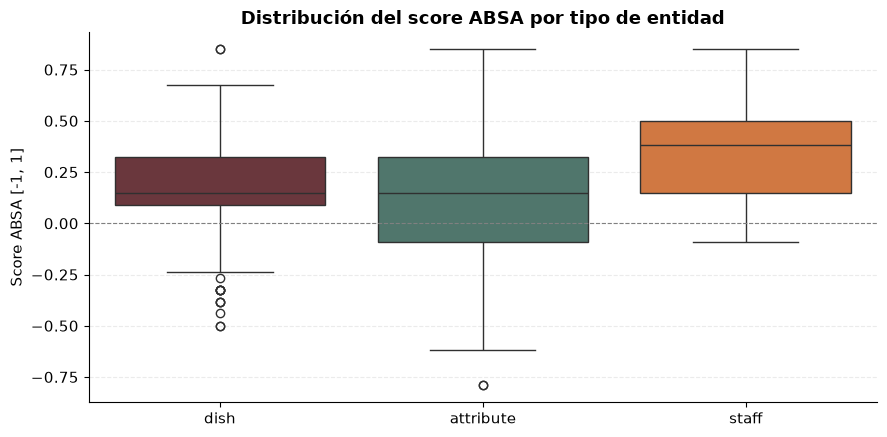

In [13]:
# ── Validación: ¿el ABSA agregado por reseña es coherente con el Sentimiento global? ─
review_level_absa = (
    absa_table.groupby('review_id')['absa_score'].mean().rename('avg_absa_score')
)
validation = reviews_unified.set_index('review_id')[['sentiment_source']].join(review_level_absa).dropna()
validation['avg_absa_label'] = validation['avg_absa_score'].map(sentiment_label)

crosstab = pd.crosstab(validation['sentiment_source'], validation['avg_absa_label'], normalize='index').round(2)
print('Concordancia entre Sentimiento (fuente) y ABSA medio agregado por reseña:')
print(crosstab)

fig, ax = plt.subplots(figsize=(9, 4.5))
sns.boxplot(
    data=absa_table, x='entity_type', y='absa_score', hue='entity_type',
    palette=PALETTE, legend=False, ax=ax,
)
ax.axhline(0, color='grey', linewidth=0.8, linestyle='--')
ax.set_title('Distribución del score ABSA por tipo de entidad')
ax.set_xlabel('')
ax.set_ylabel('Score ABSA [-1, 1]')
plt.tight_layout()
plt.savefig(FIGURES_DIR / '03_distribucion_absa.png')
plt.show()

## 1.6 Persistencia Silver

Guardamos dos artefactos: la tabla de reseñas unificadas y enriquecidas (una fila por reseña) y la tabla ABSA en formato largo (una fila por mención de entidad). Las columnas de lista (`dishes_raw`, `dishes_detected`, ...) se serializan a JSON para que el parquet no falle con tipos objeto anidados.

In [14]:
def save_silver_outputs(reviews: pd.DataFrame, absa: pd.DataFrame, silver_dir: Path) -> None:
    '''
    Persist the Silver review and ABSA tables as Parquet, plus a JSON sample.

    List-typed columns are JSON-encoded before writing to Parquet since pyarrow
    cannot infer a stable type for heterogeneous Python lists of strings across
    the whole column when some rows are empty lists.
    '''
    list_columns = ['dishes_raw', 'dishes_detected', 'staff_detected', 'attributes_detected']
    reviews_to_save = reviews.copy()
    for col in list_columns:
        reviews_to_save[col] = reviews_to_save[col].map(json.dumps)

    try:
        reviews_to_save.to_parquet(silver_dir / 'resenas_silver.parquet', index=False)
        absa.to_parquet(silver_dir / 'resenas_absa_silver.parquet', index=False)
    except (ImportError, OSError) as exc:
        raise RuntimeError(
            'No se pudo escribir Parquet (¿falta pyarrow/fastparquet?). '
            f'Error original: {exc}'
        ) from exc

    sample_path = silver_dir / 'resenas_silver_sample.json'
    sample_records = json.loads(reviews.head(20).to_json(orient='records', date_format='iso', force_ascii=False))
    sample_path.write_text(json.dumps(sample_records, indent=2, ensure_ascii=False), encoding='utf-8')

    print(f'Guardado: {silver_dir / "resenas_silver.parquet"} ({len(reviews)} filas)')
    print(f'Guardado: {silver_dir / "resenas_absa_silver.parquet"} ({len(absa)} filas)')
    print(f'Guardado: {sample_path} (muestra JSON, 20 filas)')


save_silver_outputs(reviews_unified, absa_table, SILVER_SNAP)

Guardado: C:\Users\CandelaGB\Desktop\TFM anita\TFM-Hosteleria-AI\data\silver\snapshots\resenas_silver.parquet (965 filas)
Guardado: C:\Users\CandelaGB\Desktop\TFM anita\TFM-Hosteleria-AI\data\silver\snapshots\resenas_absa_silver.parquet (866 filas)
Guardado: C:\Users\CandelaGB\Desktop\TFM anita\TFM-Hosteleria-AI\data\silver\snapshots\resenas_silver_sample.json (muestra JSON, 20 filas)


# SECCIÓN 2 · CAPA GOLD Y ESTUDIO DE NEGOCIO (KPIs & Visual Analytics)

A partir de la tabla ABSA en formato largo construimos las tablas agregadas de negocio (Gold) y las visualizaciones pensadas para presentar directamente al dueño del restaurante.

## 2.1 Matriz de rendimiento de carta

Clasificamos cada plato canónico en un cuadrante según dos ejes: **frecuencia de mención** (proxy de popularidad/tracción) y **sentimiento ABSA medio** (satisfacción). Los cortes se fijan en la mediana de cada eje sobre los platos con al menos 3 menciones:

- **Estrella** — alta frecuencia + alta satisfacción → proteger y destacar en carta.
- **Problema** — alta frecuencia + baja satisfacción → foco de mejora inmediato (impacta a muchos clientes).
- **Oportunidad** — baja frecuencia + alta satisfacción → joyas escondidas, candidatas a mayor visibilidad/recomendación del camarero.
- **Bajo interés** — baja frecuencia + baja satisfacción → candidatos a revisar o retirar.

In [15]:
MenuQuadrant = Literal['Estrella', 'Problema', 'Oportunidad', 'Bajo interés']


def classify_menu_quadrant(frequency: float, avg_sentiment: float,
                            freq_threshold: float, sentiment_threshold: float) -> MenuQuadrant:
    '''Classify a dish into a quadrant given popularity/satisfaction thresholds.'''
    high_frequency = frequency >= freq_threshold
    high_sentiment = avg_sentiment >= sentiment_threshold
    if high_frequency and high_sentiment:
        return 'Estrella'
    if high_frequency and not high_sentiment:
        return 'Problema'
    if not high_frequency and high_sentiment:
        return 'Oportunidad'
    return 'Bajo interés'


MIN_MENTIONS_FOR_MATRIX = 3

dish_absa = absa_table[absa_table['entity_type'] == 'dish']
dish_kpis = (
    dish_absa.groupby('entity_name')
    .agg(
        mentions=('absa_score', 'size'),
        avg_sentiment=('absa_score', 'mean'),
        pct_negative=('absa_label', lambda s: (s == 'Negativo').mean()),
    )
    .query('mentions >= @MIN_MENTIONS_FOR_MATRIX')
    .reset_index()
    .rename(columns={'entity_name': 'dish'})
)
dish_kpis['en_carta_actual'] = dish_kpis['dish'].map(dish_menu_status)

freq_threshold = dish_kpis['mentions'].median()
sentiment_threshold = dish_kpis['avg_sentiment'].median()
dish_kpis['quadrant'] = dish_kpis.apply(
    lambda r: classify_menu_quadrant(r['mentions'], r['avg_sentiment'], freq_threshold, sentiment_threshold),
    axis=1,
)

print(f'Platos analizados (≥{MIN_MENTIONS_FOR_MATRIX} menciones): {len(dish_kpis)}')
dish_kpis.sort_values('mentions', ascending=False)

Platos analizados (≥3 menciones): 27


,dish,mentions,avg_sentiment,pct_negative,en_carta_actual,quadrant
7,Croquetas,36,0.136188,0.194444,True,Problema
16,Ravioli de Rabo de Toro,27,0.167282,0.074074,True,Problema
12,Kimuchi de Marisco,16,0.185130,0.062500,True,Estrella
24,Tortilla de Betanzos,15,0.156889,0.133333,True,Problema
21,Tartar de Atún,14,0.226667,0.071429,True,Estrella
2,Bombones de Foie,13,0.200684,0.153846,True,Estrella
22,Torreznos con Revolconas,13,0.123953,0.153846,False,Problema
0,Alcachofas a la Brasa,12,0.206528,0.000000,False,Estrella
3,Bravas,11,0.050909,0.272727,True,Problema
23,Torrija,11,0.089596,0.181818,True,Problema


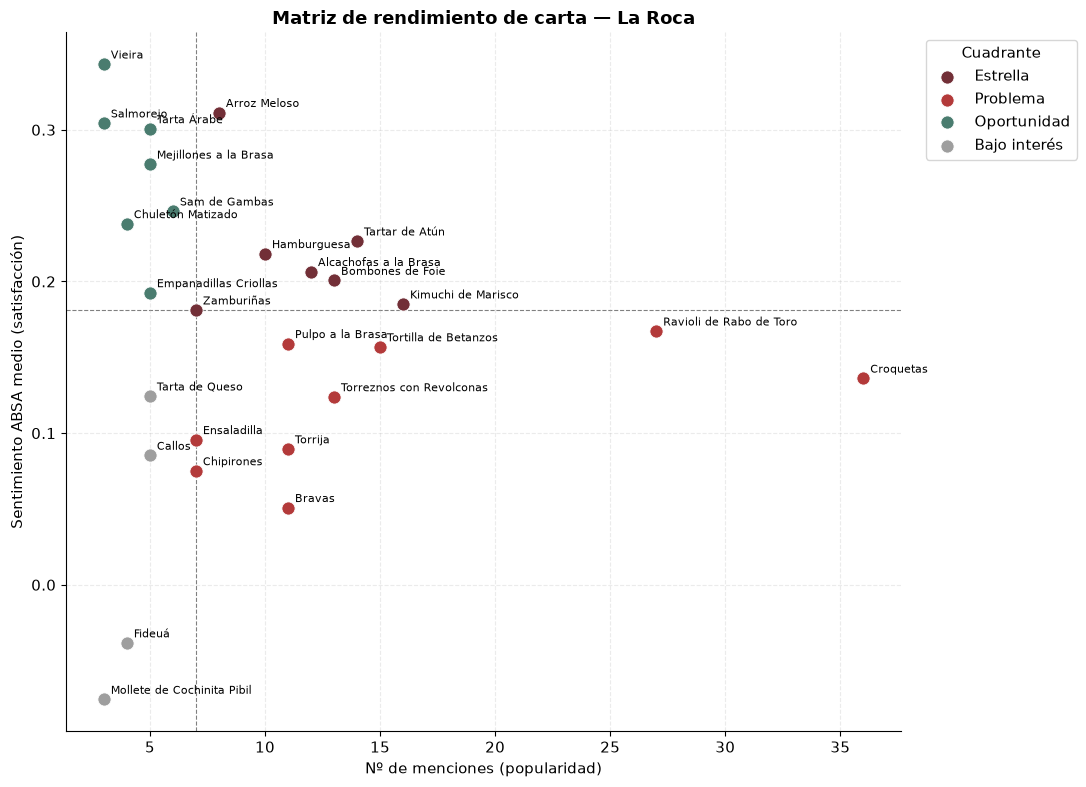

Resumen por cuadrante:
quadrant
Problema        9
Estrella        7
Oportunidad     7
Bajo interés    4
Name: count, dtype: int64


In [16]:
QUADRANT_COLORS = {
    'Estrella': COLOR_PRIMARY,
    'Problema': '#B33A3A',
    'Oportunidad': COLOR_SECONDARY,
    'Bajo interés': '#9E9E9E',
}

fig, ax = plt.subplots(figsize=(11, 8))
for quadrant, color in QUADRANT_COLORS.items():
    subset = dish_kpis[dish_kpis['quadrant'] == quadrant]
    ax.scatter(subset['mentions'], subset['avg_sentiment'], s=90, color=color,
               label=quadrant, edgecolor='white', linewidth=0.6, zorder=3)

for _, row in dish_kpis.iterrows():
    ax.annotate(row['dish'], (row['mentions'], row['avg_sentiment']),
                fontsize=8, xytext=(5, 4), textcoords='offset points')

ax.axvline(freq_threshold, color='grey', linestyle='--', linewidth=0.8, zorder=1)
ax.axhline(sentiment_threshold, color='grey', linestyle='--', linewidth=0.8, zorder=1)
ax.set_xlabel('Nº de menciones (popularidad)')
ax.set_ylabel('Sentimiento ABSA medio (satisfacción)')
ax.set_title('Matriz de rendimiento de carta — La Roca')
ax.legend(title='Cuadrante', loc='upper left', bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.savefig(FIGURES_DIR / '04_matriz_rendimiento_carta.png')
plt.show()

print('Resumen por cuadrante:')
print(dish_kpis['quadrant'].value_counts())

## 2.2 Score Calidad / Precio / Ración

Para cada plato con menciones negativas, comprobamos si esas quejas coinciden en la misma reseña con los atributos `Precio` o `Ración/Tamaño` detectados en la Sección 1.4. Esto separa "no gustó el sabor" de "no gustó lo que se paga por lo que se recibe" — información mucho más accionable para el dueño.

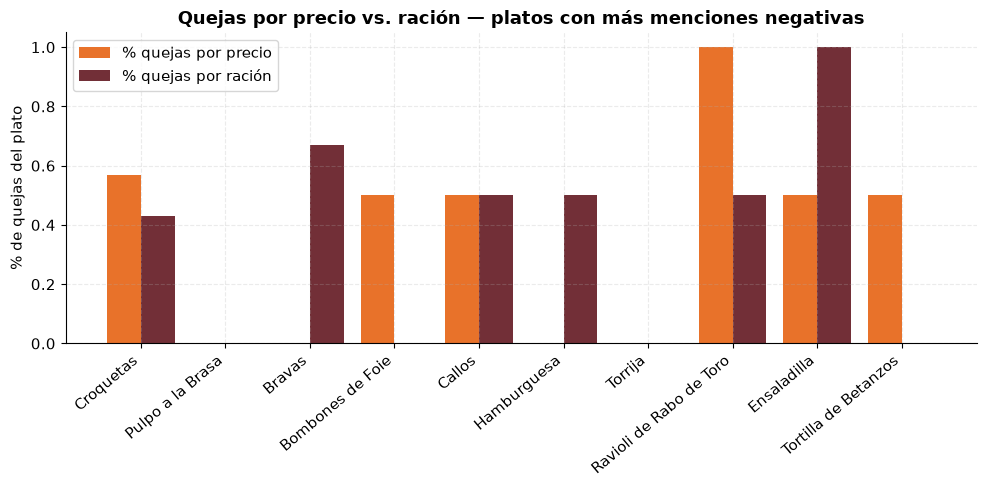

,dish,quejas_totales,quejas_precio,quejas_racion,ratio_quejas_precio,ratio_quejas_racion,mentions,avg_sentiment
4,Croquetas,7,4,3,0.57,0.43,36.0,0.136188
10,Pulpo a la Brasa,3,0,0,0.00,0.00,11.0,0.159015
1,Bravas,3,0,2,0.00,0.67,11.0,0.050909
0,Bombones de Foie,2,1,0,0.50,0.00,13.0,0.200684
2,Callos,2,1,1,0.50,0.50,5.0,0.085333
7,Hamburguesa,2,0,1,0.00,0.50,10.0,0.218333
14,Torrija,2,0,0,0.00,0.00,11.0,0.089596
11,Ravioli de Rabo de Toro,2,2,1,1.00,0.50,27.0,0.167282
5,Ensaladilla,2,1,2,0.50,1.00,7.0,0.095714
15,Tortilla de Betanzos,2,1,0,0.50,0.00,15.0,0.156889


In [17]:
review_attributes = reviews_unified.set_index('review_id')['attributes_detected']

negative_dish_mentions = dish_absa[dish_absa['absa_label'] == 'Negativo'].copy()
negative_dish_mentions['attrs'] = negative_dish_mentions['review_id'].map(review_attributes)
negative_dish_mentions['is_price_complaint'] = negative_dish_mentions['attrs'].map(
    lambda a: 'Precio' in a if isinstance(a, list) else False
)
negative_dish_mentions['is_portion_complaint'] = negative_dish_mentions['attrs'].map(
    lambda a: 'Ración/Tamaño' in a if isinstance(a, list) else False
)

quality_price_portion = (
    negative_dish_mentions.groupby('entity_name')
    .agg(
        quejas_totales=('absa_score', 'size'),
        quejas_precio=('is_price_complaint', 'sum'),
        quejas_racion=('is_portion_complaint', 'sum'),
    )
    .reset_index()
    .rename(columns={'entity_name': 'dish'})
)
quality_price_portion['ratio_quejas_precio'] = (
    quality_price_portion['quejas_precio'] / quality_price_portion['quejas_totales']
).round(2)
quality_price_portion['ratio_quejas_racion'] = (
    quality_price_portion['quejas_racion'] / quality_price_portion['quejas_totales']
).round(2)
quality_price_portion = quality_price_portion.merge(
    dish_kpis[['dish', 'mentions', 'avg_sentiment']], on='dish', how='left'
).sort_values('quejas_totales', ascending=False)

top_offenders = quality_price_portion.head(10)
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(top_offenders))
ax.bar(x - 0.2, top_offenders['ratio_quejas_precio'], width=0.4, label='% quejas por precio', color=COLOR_ACCENT)
ax.bar(x + 0.2, top_offenders['ratio_quejas_racion'], width=0.4, label='% quejas por ración', color=COLOR_PRIMARY)
ax.set_xticks(x)
ax.set_xticklabels(top_offenders['dish'], rotation=40, ha='right')
ax.set_ylabel('% de quejas del plato')
ax.set_title('Quejas por precio vs. ración — platos con más menciones negativas')
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / '05_quejas_precio_racion.png')
plt.show()

quality_price_portion

## 2.3 Impacto del personal de sala

Ranking de menciones y sentimiento medio por miembro del personal — útil tanto para reconocer al equipo como para detectar si algún nombre empieza a asociarse a experiencias negativas.

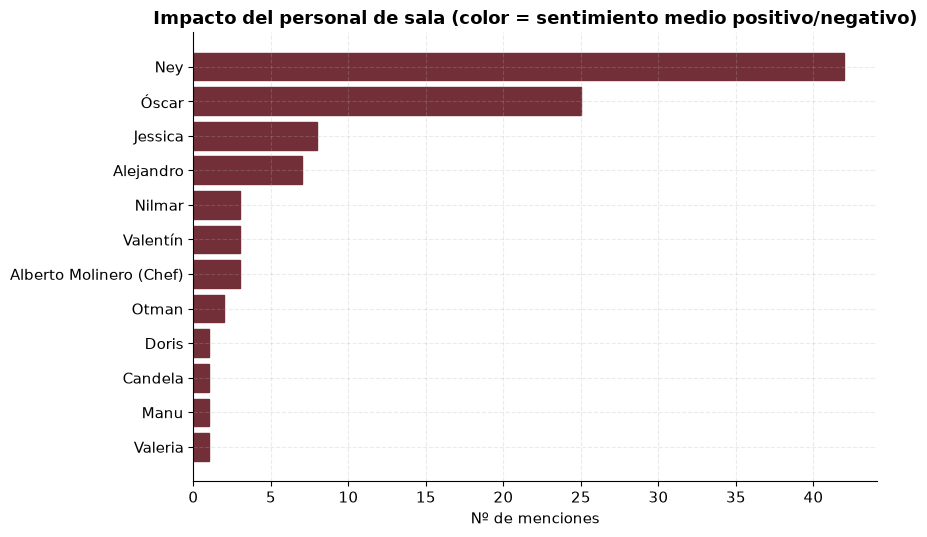

,staff_member,mentions,avg_sentiment,pct_positive
6,Ney,42,0.374074,1.000000
11,Óscar,25,0.394933,0.960000
4,Jessica,8,0.412500,1.000000
1,Alejandro,7,0.350000,1.000000
9,Valentín,3,0.383333,1.000000
7,Nilmar,3,0.383333,1.000000
0,Alberto Molinero (Chef),3,0.047778,0.333333
8,Otman,2,0.150000,1.000000
3,Doris,1,0.383333,1.000000
2,Candela,1,0.850000,1.000000


In [18]:
staff_absa = absa_table[absa_table['entity_type'] == 'staff']
staff_kpis = (
    staff_absa.groupby('entity_name')
    .agg(
        mentions=('absa_score', 'size'),
        avg_sentiment=('absa_score', 'mean'),
        pct_positive=('absa_label', lambda s: (s == 'Positivo').mean()),
    )
    .reset_index()
    .rename(columns={'entity_name': 'staff_member'})
    .sort_values('mentions', ascending=False)
)

fig, ax = plt.subplots(figsize=(9, 5.5))
ordered = staff_kpis.sort_values('mentions')
bars = ax.barh(ordered['staff_member'], ordered['mentions'], color=COLOR_PRIMARY)
for bar, sentiment in zip(bars, ordered['avg_sentiment']):
    color = COLOR_PRIMARY if sentiment >= 0 else '#B33A3A'
    bar.set_color(color)
ax.set_xlabel('Nº de menciones')
ax.set_title('Impacto del personal de sala (color = sentimiento medio positivo/negativo)')
plt.tight_layout()
plt.savefig(FIGURES_DIR / '06_impacto_personal_sala.png')
plt.show()

staff_kpis

## 2.4 Visualizaciones adicionales accionables

Tres vistas de negocio adicionales: mezcla de sentimiento por plataforma, tasa de respuesta del propietario según el sentimiento de la reseña (¿se está respondiendo más a lo positivo que a lo negativo?) y relación entre rango de precio y satisfacción.

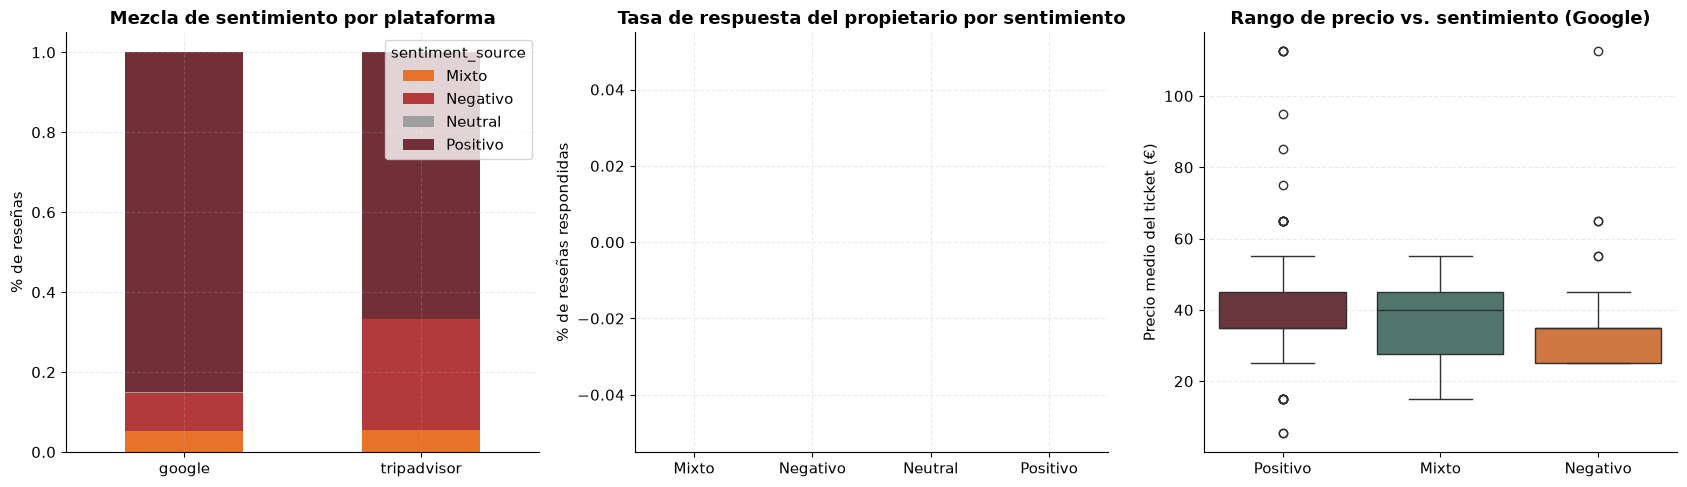

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

SENTIMENT_COLOR_MAP = {
    'Positivo': COLOR_PRIMARY, 'Mixto': COLOR_ACCENT, 'Negativo': '#B33A3A', 'Neutral': '#9E9E9E',
}

# (a) Mezcla de sentimiento por plataforma
sentiment_mix = (
    reviews_unified.groupby(['platform', 'sentiment_source']).size()
    .unstack(fill_value=0)
    .pipe(lambda d: d.div(d.sum(axis=1), axis=0))
)
mix_colors = [SENTIMENT_COLOR_MAP.get(c, '#9E9E9E') for c in sentiment_mix.columns]
sentiment_mix.plot(kind='bar', stacked=True, ax=axes[0], color=mix_colors)
axes[0].set_title('Mezcla de sentimiento por plataforma')
axes[0].set_xlabel('')
axes[0].set_ylabel('% de reseñas')
axes[0].tick_params(axis='x', rotation=0)

# (b) Tasa de respuesta del propietario según sentimiento
response_rate = reviews_unified.groupby('sentiment_source')['owner_responded'].mean().sort_index()
response_rate.plot(kind='bar', ax=axes[1], color=COLOR_SECONDARY)
axes[1].set_title('Tasa de respuesta del propietario por sentimiento')
axes[1].set_ylabel('% de reseñas respondidas')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=0)

# (c) Precio medio vs. sentimiento (solo Google, único con rango de precio)
price_sentiment = reviews_unified.dropna(subset=['price_mid'])
sns.boxplot(
    data=price_sentiment, x='sentiment_source', y='price_mid', hue='sentiment_source',
    palette=PALETTE, legend=False, ax=axes[2],
    order=['Positivo', 'Mixto', 'Negativo'],
)
axes[2].set_title('Rango de precio vs. sentimiento (Google)')
axes[2].set_xlabel('')
axes[2].set_ylabel('Precio medio del ticket (€)')

plt.tight_layout()
plt.savefig(FIGURES_DIR / '07_visualizaciones_adicionales.png')
plt.show()

## 2.5 Persistencia Gold

In [20]:
def save_gold_table(dataframe: pd.DataFrame, gold_dir: Path, name: str) -> None:
    '''Persist one Gold table as both Parquet (analytics) and CSV (easy to open in Excel).'''
    try:
        dataframe.to_parquet(gold_dir / f'{name}.parquet', index=False)
    except (ImportError, OSError) as exc:
        raise RuntimeError(f'No se pudo escribir {name}.parquet: {exc}') from exc
    dataframe.to_csv(gold_dir / f'{name}.csv', index=False, encoding='utf-8')
    print(f'Guardado: {name}.parquet / {name}.csv ({len(dataframe)} filas)')


save_gold_table(dish_kpis, GOLD_DIR, 'resenas_carta_rendimiento_gold')
save_gold_table(quality_price_portion, GOLD_DIR, 'resenas_calidad_precio_racion_gold')
save_gold_table(staff_kpis, GOLD_DIR, 'resenas_personal_sala_gold')

Guardado: resenas_carta_rendimiento_gold.parquet / resenas_carta_rendimiento_gold.csv (27 filas)
Guardado: resenas_calidad_precio_racion_gold.parquet / resenas_calidad_precio_racion_gold.csv (17 filas)
Guardado: resenas_personal_sala_gold.parquet / resenas_personal_sala_gold.csv (12 filas)


# SECCIÓN 3 · MÓDULO GEO (Generative Engine Optimization & Benchmarking)

Los buscadores conversacionales (ChatGPT, Gemini, Perplexity...) son cada vez más el punto de entrada de un cliente que busca "dónde comer en Pozuelo de Alarcón". Este módulo audita **qué dice la IA sobre La Roca** frente a su competencia, con las mismas entidades y quejas reales que hemos extraído en las Secciones 1-2 — así el análisis GEO queda anclado a la evidencia real del negocio, no a percepciones genéricas.

**Sin dependencias nuevas:** el cliente HTTP usa `urllib.request` (librería estándar), no `requests`/SDKs de terceros. Si no hay clave de API configurada en el entorno (`GROQ_API_KEY`, `GOOGLE_API_KEY`), el notebook cae automáticamente a un **modo simulación** con respuestas de ejemplo (claramente marcadas como `simulado=True`) para poder demostrar el pipeline de métricas de principio a fin sin conexión ni claves. En cuanto se define una variable de entorno con una clave real, las mismas funciones consultan la API real sin cambiar código.

## 3.1 Framework de auditoría — batería de prompts

Prompts que simulan búsquedas reales de un usuario, cubriendo ocasión, tipo de comida, terraza y grupo.

In [21]:
BRAND_NAME = 'La Roca'
ZONE_NAME = 'Pozuelo de Alarcón'


# Placeholder — sustituir por los competidores reales de la zona antes de interpretar
# el Share of Voice de forma definitiva. Se dejan 3 nombres genéricos de ejemplo para
# que el pipeline de métricas sea ejecutable de extremo a extremo.
COMPETITOR_NAMES: list[str] = ['El Urogallo Pozuelo','El Urogallo', 'Restaurante La lonja de Pozuelo', 'Restaurante Casa Luis', 'El cielo de Urrechu', 'Urrechu Zoco', 'Restaurante Pintxaki', 'Ochenta Grados Pozuelo', 'Taberna de Elia', 'Bodega La salud', 'ETXEA', 'Itakua']


@dataclass(frozen=True)
class GeoPrompt:
    '''One test prompt in the GEO audit battery.'''
    prompt_id: str
    categoria: str
    prompt: str


PROMPT_BATTERY: list[GeoPrompt] = [

    # ============================================================
    # 1. OCASIÓN / INTENCIÓN
    # ============================================================

    GeoPrompt(
        'ocasion_pareja',
        'Ocasión',
        f'Recomiéndame un restaurante romántico para cenar en pareja en {ZONE_NAME}.'
    ),

    GeoPrompt(
        'ocasion_grupo',
        'Ocasión',
        f'¿Qué restaurante me recomiendas para ir con un grupo grande de amigos en {ZONE_NAME}?'
    ),

    GeoPrompt(
        'ocasion_familia',
        'Ocasión',
        f'Busco un restaurante en {ZONE_NAME} para comer en familia con niños.'
    ),

    GeoPrompt(
        'ocasion_negocio',
        'Ocasión',
        f'¿Qué restaurantes de {ZONE_NAME} recomendarías para una comida de negocios?'
    ),

    GeoPrompt(
        'ocasion_cumpleanos',
        'Ocasión',
        f'¿Dónde recomendarías celebrar un cumpleaños o una ocasión especial en {ZONE_NAME}?'
    ),

    GeoPrompt(
        'ocasion_evento',
        'Ocasión',
        f'Necesito un restaurante en {ZONE_NAME} para celebrar un evento o celebración privada. ¿Qué opciones recomendarías?'
    ),

    # ============================================================
    # 2. TIPO DE COMIDA / PRODUCTO
    # ============================================================

    GeoPrompt(
        'tipo_tapeo',
        'Tipo de comida',
        f'¿Dónde puedo ir de tapeo o pedir raciones en {ZONE_NAME}?'
    ),

    GeoPrompt(
        'tipo_carne',
        'Tipo de comida',
        f'Recomiéndame un restaurante de carne y producto de calidad en {ZONE_NAME}.'
    ),

    GeoPrompt(
        'tipo_espanola',
        'Tipo de comida',
        f'¿Cuál es un buen restaurante de cocina española tradicional en {ZONE_NAME}?'
    ),

    GeoPrompt(
        'producto_calidad',
        'Producto',
        f'¿Dónde comer buen producto y materias primas de calidad en {ZONE_NAME}?'
    ),

    GeoPrompt(
        'cocina_tradicional',
        'Cocina',
        f'¿Qué restaurantes de cocina tradicional recomendarías en {ZONE_NAME}?'
    ),

    # ============================================================
    # 3. EXPERIENCIA
    # ============================================================

    GeoPrompt(
        'terraza',
        'Experiencia',
        f'Quiero comer en una terraza agradable en {ZONE_NAME}, ¿qué me recomiendas?'
    ),

    GeoPrompt(
        'ambiente',
        'Experiencia',
        f'¿Qué restaurantes tienen mejor ambiente para cenar en {ZONE_NAME}?'
    ),

    GeoPrompt(
        'tranquilo',
        'Experiencia',
        f'Busco un restaurante tranquilo donde poder conversar en {ZONE_NAME}. ¿Cuál recomendarías?'
    ),

    GeoPrompt(
        'bonito',
        'Experiencia',
        f'¿Qué restaurantes de {ZONE_NAME} tienen un local bonito y una experiencia especialmente agradable?'
    ),

    GeoPrompt(
        'servicio',
        'Experiencia',
        f'¿Qué restaurantes de {ZONE_NAME} destacan por tener un buen servicio?'
    ),

    # ============================================================
    # 4. PRECIO
    # ============================================================

    GeoPrompt(
        'calidad_precio',
        'Precio',
        f'¿Cuál es el mejor restaurante calidad-precio de {ZONE_NAME}?'
    ),

    GeoPrompt(
        'economico',
        'Precio',
        f'¿Dónde puedo comer bien y barato en {ZONE_NAME}?'
    ),

    GeoPrompt(
        'precio_medio',
        'Precio',
        f'¿Qué restaurantes recomendarías en {ZONE_NAME} para una comida de precio medio pero de buena calidad?'
    ),

    GeoPrompt(
        'premium',
        'Precio',
        f'¿Cuál es uno de los mejores restaurantes de gama alta en {ZONE_NAME}?'
    ),

    # ============================================================
    # 5. REPUTACIÓN
    # ============================================================

    GeoPrompt(
        'mejor_valorado',
        'Reputación',
        f'¿Cuál es el restaurante mejor valorado de {ZONE_NAME} según las reseñas de Google?'
    ),

    GeoPrompt(
        'mejores_restaurantes',
        'Reputación',
        f'¿Cuáles son los mejores restaurantes de {ZONE_NAME} que recomendarías actualmente?'
    ),

    GeoPrompt(
        'restaurante_recomendado',
        'Reputación',
        f'Si solo pudieras recomendar un restaurante en {ZONE_NAME}, ¿cuál elegirías y por qué?'
    ),

    GeoPrompt(
        'reseñas_positivas',
        'Reputación',
        f'¿Qué restaurantes de {ZONE_NAME} reciben mejores opiniones de sus clientes?'
    ),

    # ============================================================
    # 6. DESCUBRIMIENTO / COMPARACIÓN
    # ============================================================

    GeoPrompt(
        'competidores',
        'Competencia',
        f'¿Cuáles son los principales restaurantes que compiten por clientes en {ZONE_NAME}?'
    ),

    GeoPrompt(
        'alternativas',
        'Competencia',
        f'Si un restaurante está completo en {ZONE_NAME}, ¿qué alternativas similares recomendarías?'
    ),

    GeoPrompt(
        'alternativa_carne',
        'Competencia',
        f'¿Cuáles son las mejores alternativas para comer carne en {ZONE_NAME}?'
    ),

    GeoPrompt(
        'comparativa',
        'Competencia',
        f'Compara los mejores restaurantes de {ZONE_NAME} para una comida de calidad y dime cuál recomendarías.'
    ),

    # ============================================================
    # 7. PREGUNTAS MÁS "GEO" / DESCUBRIMIENTO LOCAL
    # ============================================================

    GeoPrompt(
        'cerca_centro',
        'Localización',
        f'¿Qué restaurantes recomendarías cerca del centro de {ZONE_NAME}?'
    ),

    GeoPrompt(
        'zona_residencial',
        'Localización',
        f'¿Qué restaurantes son especialmente recomendables para alguien que vive en {ZONE_NAME}?'
    ),

    GeoPrompt(
        'plan_zona',
        'Localización',
        f'Quiero hacer un plan de comida o cena en {ZONE_NAME}. ¿Qué restaurantes recomendarías?'
    ),

    GeoPrompt(
        'despues_trabajo',
        'Localización',
        f'¿Dónde recomendarías ir a comer o cenar después del trabajo en {ZONE_NAME}?'
    ),

    # ============================================================
    # 8. INTENCIÓN DE COMPRA
    # ============================================================

    GeoPrompt(
        'reservar',
        'Conversión',
        f'Quiero reservar mesa en un buen restaurante de {ZONE_NAME}. ¿Qué me recomiendas?'
    ),

    GeoPrompt(
        'cena_hoy',
        'Conversión',
        f'Quiero cenar hoy en un buen restaurante de {ZONE_NAME}. ¿Qué opciones me recomendarías?'
    ),

    GeoPrompt(
        'comida_fin_semana',
        'Conversión',
        f'Quiero comer este fin de semana en {ZONE_NAME}. ¿Qué restaurante recomendarías?'
    ),

    GeoPrompt(
        'primera_visita',
        'Conversión',
        f'Es mi primera vez en {ZONE_NAME}. ¿En qué restaurante debería comer para tener una buena experiencia?'
    ),

    # ============================================================
    # 9. ATRIBUTOS CONCRETOS
    # ============================================================

    GeoPrompt(
        'buena_atencion',
        'Atributos',
        f'¿Qué restaurantes de {ZONE_NAME} destacan por su atención al cliente?'
    ),

    GeoPrompt(
        'buena_comida',
        'Atributos',
        f'¿Dónde se come especialmente bien en {ZONE_NAME}?'
    ),

    GeoPrompt(
        'cantidad',
        'Atributos',
        f'¿Qué restaurantes de {ZONE_NAME} destacan por ofrecer buenas cantidades de comida?'
    ),

    GeoPrompt(
        'producto',
        'Atributos',
        f'¿Qué restaurantes de {ZONE_NAME} destacan por la calidad de su producto?'
    ),

    GeoPrompt(
        'postres',
        'Atributos',
        f'¿Qué restaurantes de {ZONE_NAME} recomendarías especialmente por sus postres?'
    ),

    # ============================================================
    # 10. PERCEPCIÓN DE MARCA
    # ============================================================

    GeoPrompt(
        'que_sabes',
        'Marca',
        f'¿Qué sabes sobre los restaurantes más conocidos de {ZONE_NAME}?'
    ),

    GeoPrompt(
        'restaurante_destacado',
        'Marca',
        f'¿Qué restaurante representa mejor la oferta gastronómica de {ZONE_NAME}?'
    ),

    GeoPrompt(
        'restaurante_local',
        'Marca',
        f'¿Qué restaurante recomendarías a alguien que busca un sitio auténtico y local en {ZONE_NAME}?'
    ),

    GeoPrompt(
        'restaurante_especial',
        'Marca',
        f'¿Qué restaurante de {ZONE_NAME} ofrece una experiencia que destaque frente a los demás?'
    ),
]

print(f'Batería de prompts: {len(PROMPT_BATTERY)} prompts en {len(set(p.categoria for p in PROMPT_BATTERY))} categorías')
pd.DataFrame([p.__dict__ for p in PROMPT_BATTERY])

Batería de prompts: 45 prompts en 12 categorías


,prompt_id,categoria,prompt
0,ocasion_pareja,Ocasión,Recomiéndame un restaurante romántico para cenar en pareja en Pozuelo de Alarcón.
1,ocasion_grupo,Ocasión,¿Qué restaurante me recomiendas para ir con un grupo grande de amigos en Pozuelo de Alarcón?
2,ocasion_familia,Ocasión,Busco un restaurante en Pozuelo de Alarcón para comer en familia con niños.
3,ocasion_negocio,Ocasión,¿Qué restaurantes de Pozuelo de Alarcón recomendarías para una comida de negocios?
4,ocasion_cumpleanos,Ocasión,¿Dónde recomendarías celebrar un cumpleaños o una ocasión especial en Pozuelo de Alarcón?
5,ocasion_evento,Ocasión,Necesito un restaurante en Pozuelo de Alarcón para celebrar un evento o celebración privada. ¿Qué opciones recomenda...
6,tipo_tapeo,Tipo de comida,¿Dónde puedo ir de tapeo o pedir raciones en Pozuelo de Alarcón?
7,tipo_carne,Tipo de comida,Recomiéndame un restaurante de carne y producto de calidad en Pozuelo de Alarcón.
8,tipo_espanola,Tipo de comida,¿Cuál es un buen restaurante de cocina española tradicional en Pozuelo de Alarcón?
9,producto_calidad,Producto,¿Dónde comer buen producto y materias primas de calidad en Pozuelo de Alarcón?


## 3.2 Cliente LLM multi-proveedor (stdlib, sin dependencias nuevas)

Un `urllib.request` genérico por proveedor. Cada función lee su clave de un `os.environ` estándar del proveedor y lanza `RuntimeError` con un mensaje claro si falla la llamada — nunca deja pasar una excepción cruda de red hacia el resto del pipeline.

In [22]:
import os
import time
import urllib.error
import urllib.request


LLMProvider = Literal['groq', 'gemini']

API_ENDPOINTS: dict[LLMProvider, str] = {
    'groq': 'https://api.groq.com/openai/v1/chat/completions',
    'gemini': 'https://generativelanguage.googleapis.com/v1beta/models/gemini-2.5-flash:generateContent',
}
API_KEY_ENV_VARS: dict[LLMProvider, str] = {
    'groq': 'GROQ_API_KEY',
    'gemini': 'GOOGLE_API_KEY',
}
REQUEST_TIMEOUT_SECONDS = 30


def _post_json(url: str, headers: dict[str, str], payload: dict[str, Any], max_retries: int = 2) -> dict[str, Any]:
    '''POST a JSON payload with urllib and return the parsed JSON response.

    Reintenta una vez (con una pausa breve) ante fallos de red o HTTP 429/5xx --
    la bateria hace decenas de llamadas seguidas sin espaciarlas, y un fallo
    puntual de un unico intento no deberia degradar esa respuesta a simulada.
    '''
    headers = {**headers, 'User-Agent': 'Mozilla/5.0 (compatible; TFM-La-Roca-GEO-audit/1.0)'}
    request_body = json.dumps(payload).encode('utf-8')
    last_exc: Exception | None = None
    for attempt in range(max_retries + 1):
        request = urllib.request.Request(url, data=request_body, headers=headers, method='POST')
        try:
            with urllib.request.urlopen(request, timeout=REQUEST_TIMEOUT_SECONDS) as response:
                return json.loads(response.read().decode('utf-8'))
        except urllib.error.HTTPError as exc:
            body = exc.read().decode('utf-8', 'ignore')
            last_exc = RuntimeError(f'HTTP {exc.code} llamando a {url}: {body}')
            if exc.code == 429 or exc.code >= 500:
                time.sleep(1.5 * (attempt + 1))
                continue
            raise last_exc from exc
        except urllib.error.URLError as exc:
            last_exc = RuntimeError(f'Error de red llamando a {url}: {exc.reason}')
            time.sleep(1.5 * (attempt + 1))
            continue
    raise last_exc


def call_groq(prompt: str, api_key: str, model: str = 'openai/gpt-oss-120b') -> str:
    '''Call the Groq Chat Completions API (api.groq.com) -- misma forma que OpenAI
    Chat Completions, Groq expone un endpoint compatible. Verificar el nombre de
    modelo vigente en https://console.groq.com/docs/models antes de una ejecucion
    real si esto lleva tiempo sin tocarse (el catalogo de modelos cambia).'''
    payload = {'model': model, 'messages': [{'role': 'user', 'content': prompt}], 'temperature': 0.3}
    headers = {'Authorization': f'Bearer {api_key}', 'Content-Type': 'application/json'}
    data = _post_json(API_ENDPOINTS['groq'], headers, payload)
    return data['choices'][0]['message']['content']


def call_gemini(prompt: str, api_key: str) -> str:
    '''Call the Gemini generateContent API and return the assistant text.'''
    payload = {'contents': [{'parts': [{'text': prompt}]}]}
    headers = {'Content-Type': 'application/json'}
    url = f"{API_ENDPOINTS['gemini']}?key={api_key}"
    data = _post_json(url, headers, payload)
    return data['candidates'][0]['content']['parts'][0]['text']


_LLM_CALLERS: dict[LLMProvider, Any] = {
    'groq': call_groq, 'gemini': call_gemini,
}

# ── Respuestas simuladas (modo offline / sin API key) ─────────────────────────
# Texto de ejemplo plausible para poder demostrar el pipeline de métricas sin
# conexión ni claves. Se marcan explícitamente como `simulado=True` en la salida
# de `query_llm` y NO deben interpretarse como respuestas reales de ningún LLM.
MOCK_RESPONSE_TEMPLATE = (
    "[SIMULACIÓN] Para tu búsqueda sobre '{prompt_categoria}' en {zone}, un restaurante muy "
    "recomendado es {brand}, conocido por sus raciones para compartir y su terraza. También se "
    "suele mencionar {competitor}. Algunos comentarios señalan que las raciones pueden ser algo "
    "pequeñas para el precio."
)


def query_llm(provider: LLMProvider, geo_prompt: GeoPrompt) -> dict[str, Any]:
    '''
    Query one LLM provider for one prompt, falling back to a labeled mock
    response when no API key is configured or the call fails.
    '''
    api_key = os.environ.get(API_KEY_ENV_VARS[provider])
    if api_key:
        try:
            text = _LLM_CALLERS[provider](geo_prompt.prompt, api_key)
            return {
                'provider': provider, 'prompt_id': geo_prompt.prompt_id,
                'categoria': geo_prompt.categoria, 'response_text': text,
                'simulado': False, 'error': None,
            }
        except RuntimeError as exc:
            warnings.warn(f'[{provider}] fallo en llamada real, se usa simulación: {exc}')

    mock_text = MOCK_RESPONSE_TEMPLATE.format(
        prompt_categoria=geo_prompt.categoria, zone=ZONE_NAME, brand=BRAND_NAME,
        competitor=COMPETITOR_NAMES[0],
    )
    return {
        'provider': provider, 'prompt_id': geo_prompt.prompt_id,
        'categoria': geo_prompt.categoria, 'response_text': mock_text,
        'simulado': True, 'error': None if api_key else 'sin API key configurada',
    }

## 3.3 Ejecución de la batería

Se consulta cada proveedor configurado para cada prompt. Por defecto se incluyen los tres proveedores; si ninguno tiene clave configurada, el notebook se ejecuta igualmente en modo simulación (útil para revisar/depurar el pipeline antes de gastar cuota de API real).

In [23]:
def run_geo_audit(providers: list[LLMProvider], prompts: list[GeoPrompt]) -> pd.DataFrame:
    '''Run the full prompt battery against every provider and collect the results.'''
    results = [query_llm(provider, prompt) for provider in providers for prompt in prompts]
    return pd.DataFrame(results)


GEO_PROVIDERS: list[LLMProvider] = ['gemini', 'groq']
geo_responses = run_geo_audit(GEO_PROVIDERS, PROMPT_BATTERY)

n_simulated = geo_responses['simulado'].sum()
print(f'Respuestas recogidas: {len(geo_responses)} ({n_simulated} simuladas, '
      f'{len(geo_responses) - n_simulated} reales)')
geo_responses.head(5)

Respuestas recogidas: 90 (63 simuladas, 27 reales)


,provider,prompt_id,categoria,response_text,simulado,error
0,gemini,ocasion_pareja,Ocasión,"[SIMULACIÓN] Para tu búsqueda sobre 'Ocasión' en Pozuelo de Alarcón, un restaurante muy recomendado es La Roca, cono...",True,None
1,gemini,ocasion_grupo,Ocasión,"[SIMULACIÓN] Para tu búsqueda sobre 'Ocasión' en Pozuelo de Alarcón, un restaurante muy recomendado es La Roca, cono...",True,None
2,gemini,ocasion_familia,Ocasión,"[SIMULACIÓN] Para tu búsqueda sobre 'Ocasión' en Pozuelo de Alarcón, un restaurante muy recomendado es La Roca, cono...",True,None
3,gemini,ocasion_negocio,Ocasión,"[SIMULACIÓN] Para tu búsqueda sobre 'Ocasión' en Pozuelo de Alarcón, un restaurante muy recomendado es La Roca, cono...",True,None
4,gemini,ocasion_cumpleanos,Ocasión,"[SIMULACIÓN] Para tu búsqueda sobre 'Ocasión' en Pozuelo de Alarcón, un restaurante muy recomendado es La Roca, cono...",True,None


## 3.4 Métricas GEO

- **Share of Voice (SoV)** — % de respuestas que mencionan a La Roca, por proveedor y frente a cada competidor configurado.
- **Consenso semántico** — qué atributos reales (del diccionario de la Sección 1.4) asocia cada IA a La Roca en sus respuestas.
- **Alertas** — ¿la IA repite espontáneamente alguna de las quejas reales detectadas en el ABSA (p. ej. raciones pequeñas, precio)? Es señal de que el problema ya ha calado en la percepción pública, no solo en las reseñas.

In [24]:
def compute_share_of_voice(responses: pd.DataFrame, brand: str, competitors: list[str]) -> pd.DataFrame:
    '''
    Compute, per provider, the share of responses mentioning the brand and
    each competitor.

    Parameters
    ----------
    responses : pandas.DataFrame
        Output of `run_geo_audit` (needs `provider` and `response_text`).
    brand : str
        Brand name to search for (case/accent-insensitive substring match).
    competitors : list[str]
        Competitor names to compare against.

    Returns
    -------
    pandas.DataFrame
        One row per provider, one column per entity (brand + competitors)
        with the mention rate in [0, 1].
    '''
    entities = {brand: brand, **{c: c for c in competitors}}
    rows = []
    for provider, group in responses.groupby('provider'):
        row = {'provider': provider, 'n_respuestas': len(group)}
        for label, name in entities.items():
            key = normalize_text(name)
            row[label] = group['response_text'].map(normalize_text).str.contains(key, regex=False).mean()
        rows.append(row)
    return pd.DataFrame(rows).set_index('provider')


sov_table = compute_share_of_voice(geo_responses, BRAND_NAME, COMPETITOR_NAMES)
print('Share of Voice por proveedor (% de respuestas que mencionan a cada marca):')
sov_table.round(2)

Share of Voice por proveedor (% de respuestas que mencionan a cada marca):


,n_respuestas,La Roca,El Urogallo Pozuelo,El Urogallo,Restaurante La lonja de Pozuelo,Restaurante Casa Luis,El cielo de Urrechu,Urrechu Zoco,Restaurante Pintxaki,Ochenta Grados Pozuelo,Taberna de Elia,Bodega La salud,ETXEA,Itakua
provider,,,,,,,,,,,,,,
gemini,45,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
groq,45,0.4,0.4,0.4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [25]:
# ── Consenso semántico: reutiliza el diccionario de atributos de la Sección 1.4 ─
geo_responses['attributes_mentioned'] = geo_responses['response_text'].map(extract_attributes)
geo_responses['brand_mentioned'] = geo_responses['response_text'].map(
    lambda t: normalize_text(BRAND_NAME) in normalize_text(t)
)

semantic_consensus = (
    geo_responses[geo_responses['brand_mentioned']]
    .explode('attributes_mentioned')
    .dropna(subset=['attributes_mentioned'])
    .groupby('attributes_mentioned').size()
    .rename('menciones_ia')
    .sort_values(ascending=False)
    .to_frame()
)
print('Atributos que la IA asocia a La Roca cuando la menciona:')
print(semantic_consensus if not semantic_consensus.empty else '(sin menciones de marca en la muestra)')

# ── Alertas: ¿la IA repite quejas reales detectadas en el ABSA? ───────────────
# Atributos con más carga negativa real, según las menciones negativas del corpus.
attr_absa = absa_table[absa_table['entity_type'] == 'attribute']
KNOWN_NEGATIVE_ATTRIBUTES: list[str] = (
    attr_absa.groupby('entity_name')['absa_score'].mean()
    .loc[lambda s: s < 0].index.tolist()
)
print(f'\nAtributos con quejas reales en las reseñas: {KNOWN_NEGATIVE_ATTRIBUTES}')


def detect_alerts(attributes_mentioned: list[str], known_complaints: list[str]) -> list[str]:
    '''Flag which real, data-driven complaints the AI response echoes spontaneously.'''
    return [a for a in attributes_mentioned if a in known_complaints]


geo_responses['alerts'] = geo_responses['attributes_mentioned'].map(
    lambda attrs: detect_alerts(attrs, KNOWN_NEGATIVE_ATTRIBUTES)
)
alert_rate_by_provider = geo_responses.groupby('provider')['alerts'].apply(
    lambda s: (s.map(len) > 0).mean()
)
print('\n% de respuestas por proveedor que repiten espontáneamente una queja real conocida:')
print(alert_rate_by_provider.round(2))

Atributos que la IA asocia a La Roca cuando la menciona:
                      menciones_ia
attributes_mentioned              
Precio                          63
Ración/Tamaño                   63
Terraza                         63

Atributos con quejas reales en las reseñas: ['Limpieza']

% de respuestas por proveedor que repiten espontáneamente una queja real conocida:
provider
gemini    0.0
groq      0.0
Name: alerts, dtype: float64


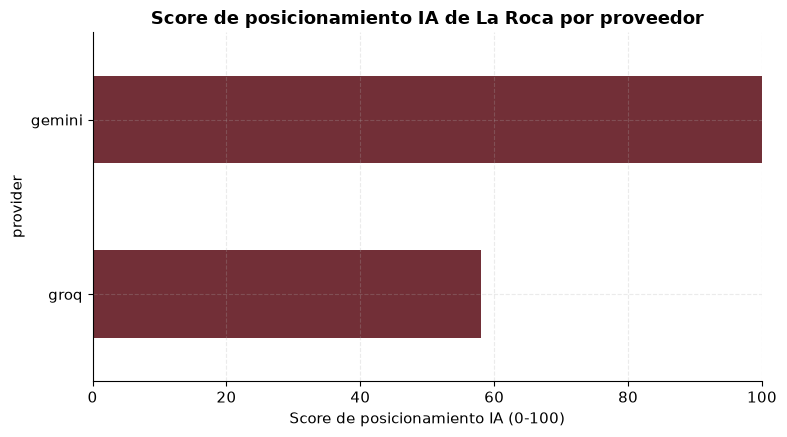

,share_of_voice,tasa_alertas_quejas_reales,score_posicionamiento_ia
provider,,,
gemini,1.0,0.0,100.0
groq,0.4,0.0,58.0


In [26]:
def compute_ai_positioning_score(sov: pd.Series, alert_rate: pd.Series, weight_sov: float = 0.7) -> pd.Series:
    '''
    Composite AI-positioning score per provider in [0, 100].

    Blends visibility (SoV, weight `weight_sov`) with a penalty for how often
    the AI spontaneously echoes a known real complaint (weight `1 - weight_sov`).
    A high alert rate is not necessarily "bad" — it means the AI has already
    absorbed the complaint into its public narrative — but it does lower the
    pure positioning score, since it signals unresolved reputational risk.
    '''
    aligned_alert_rate = alert_rate.reindex(sov.index).fillna(0.0)
    score = weight_sov * sov + (1 - weight_sov) * (1 - aligned_alert_rate)
    return (score * 100).round(1)


geo_scorecard = pd.DataFrame({
    'share_of_voice': sov_table[BRAND_NAME],
    'tasa_alertas_quejas_reales': alert_rate_by_provider,
})
geo_scorecard['score_posicionamiento_ia'] = compute_ai_positioning_score(
    geo_scorecard['share_of_voice'], geo_scorecard['tasa_alertas_quejas_reales']
)

fig, ax = plt.subplots(figsize=(8, 4.5))
geo_scorecard['score_posicionamiento_ia'].sort_values().plot(kind='barh', ax=ax, color=COLOR_PRIMARY)
ax.set_xlabel('Score de posicionamiento IA (0-100)')
ax.set_title(f'Score de posicionamiento IA de {BRAND_NAME} por proveedor')
ax.set_xlim(0, 100)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '08_geo_score_posicionamiento.png')
plt.show()

geo_scorecard.round(2)

## 3.5 Persistencia GEO

In [27]:
geo_responses_to_save = geo_responses.copy()
for col in ('attributes_mentioned', 'alerts'):
    geo_responses_to_save[col] = geo_responses_to_save[col].map(json.dumps)

save_gold_table(geo_responses_to_save, GOLD_DIR, 'geo_respuestas_llm_gold')
save_gold_table(sov_table.reset_index(), GOLD_DIR, 'geo_share_of_voice_gold')
save_gold_table(geo_scorecard.reset_index(names='provider'), GOLD_DIR, 'geo_scorecard_gold')

Guardado: geo_respuestas_llm_gold.parquet / geo_respuestas_llm_gold.csv (90 filas)
Guardado: geo_share_of_voice_gold.parquet / geo_share_of_voice_gold.csv (2 filas)
Guardado: geo_scorecard_gold.parquet / geo_scorecard_gold.csv (2 filas)


# SECCIÓN 4 · IDEAS EXTRA Y PROPUESTAS DE VALOR AÑADIDO

Tres análisis adicionales, pensados para pasar de "informe" a "herramienta de gestión" del día a día del restaurante.

## 4.1 Detección de caída temporal de calidad

Media móvil mensual del sentimiento global de las reseñas, con una alerta automática cuando el último mes disponible cae más de 1.5 desviaciones estándar por debajo de la media histórica — una señal temprana de que algo se ha deteriorado (cambio de proveedor, rotación de personal, etc.) antes de que se note en la facturación.

Chequeo de caída de calidad reciente: {'is_alert': np.False_, 'last_month': Timestamp('2026-07-01 00:00:00'), 'last_value': np.float64(0.147), 'historic_mean': np.float64(0.146), 'z_score': np.float64(0.01)}


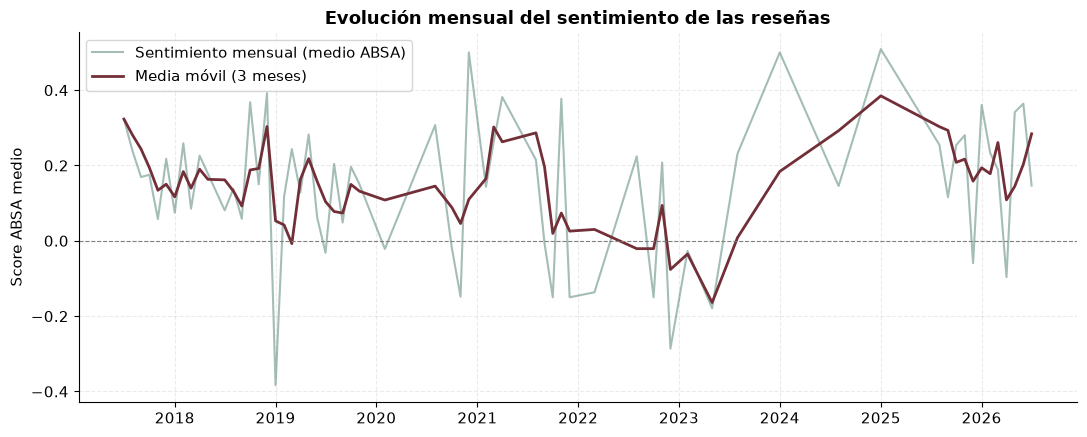

In [28]:
def detect_quality_drop(monthly_sentiment: pd.Series, z_threshold: float = 1.5) -> dict[str, Any]:
    '''
    Flag whether the most recent month is an anomalous quality drop.

    Parameters
    ----------
    monthly_sentiment : pandas.Series
        Mean sentiment score indexed by month (chronological order).
    z_threshold : float, default=1.5
        Number of standard deviations below the historical mean that
        triggers the alert.

    Returns
    -------
    dict[str, Any]
        `is_alert`, `last_month`, `last_value`, `historic_mean`, `z_score`.
    '''
    if len(monthly_sentiment) < 4:
        return {'is_alert': False, 'reason': 'serie demasiado corta para evaluar (<4 meses)'}

    history = monthly_sentiment.iloc[:-1]
    last_month, last_value = monthly_sentiment.index[-1], monthly_sentiment.iloc[-1]
    historic_mean, historic_std = history.mean(), history.std()

    if historic_std == 0 or pd.isna(historic_std):
        return {'is_alert': False, 'reason': 'sin variabilidad histórica suficiente'}

    z_score = (last_value - historic_mean) / historic_std
    return {
        'is_alert': z_score < -z_threshold,
        'last_month': last_month, 'last_value': round(last_value, 3),
        'historic_mean': round(historic_mean, 3), 'z_score': round(z_score, 2),
    }


review_sentiment_series = reviews_unified.set_index('review_id')['review_date'].to_frame().join(review_level_absa)
monthly_quality = (
    review_sentiment_series.dropna()
    .assign(month=lambda d: d['review_date'].dt.to_period('M').dt.to_timestamp())
    .groupby('month')['avg_absa_score'].mean()
    .sort_index()
)
rolling_quality = monthly_quality.rolling(window=3, min_periods=1).mean()

quality_alert = detect_quality_drop(monthly_quality)
print('Chequeo de caída de calidad reciente:', quality_alert)

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(monthly_quality.index, monthly_quality.values, color=COLOR_SECONDARY, alpha=0.5, label='Sentimiento mensual (medio ABSA)')
ax.plot(rolling_quality.index, rolling_quality.values, color=COLOR_PRIMARY, linewidth=2, label='Media móvil (3 meses)')
if quality_alert.get('is_alert'):
    ax.scatter([quality_alert['last_month']], [quality_alert['last_value']], color='#B33A3A', s=120,
               zorder=5, label='⚠ Alerta de caída de calidad')
ax.axhline(0, color='grey', linewidth=0.8, linestyle='--')
ax.set_title('Evolución mensual del sentimiento de las reseñas')
ax.set_ylabel('Score ABSA medio')
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / '09_evolucion_calidad_temporal.png')
plt.show()

## 4.2 Alertas de reseñas negativas críticas sin responder

Lista accionable de reseñas negativas de los últimos 6 meses que **no** tienen respuesta del propietario, ordenadas por antigüedad — las más urgentes de contestar primero. Se exporta a CSV para que el equipo de sala/dirección pueda trabajarla directamente.

In [29]:
RECENT_WINDOW_MONTHS = 6

latest_review_date = reviews_unified['review_date'].max()
recent_cutoff = latest_review_date - pd.DateOffset(months=RECENT_WINDOW_MONTHS)

critical_unanswered = (
    reviews_unified[
        (reviews_unified['sentiment_source'] == 'Negativo')
        & (~reviews_unified['owner_responded'])
        & (reviews_unified['review_date'] >= recent_cutoff)
    ]
    [['review_id', 'platform', 'author', 'review_date', 'negative_aspects_text', 'review_text']]
    .sort_values('review_date')
    .reset_index(drop=True)
)

alerts_path = GOLD_DIR / 'alertas_resenas_criticas_sin_responder.csv'
critical_unanswered.to_csv(alerts_path, index=False, encoding='utf-8')

print(f'Ventana analizada: desde {recent_cutoff.date()} hasta {latest_review_date.date()}')
print(f'Reseñas negativas SIN respuesta en los últimos {RECENT_WINDOW_MONTHS} meses: {len(critical_unanswered)}')
print(f'Exportado a: {alerts_path}')
critical_unanswered.head(10)

Ventana analizada: desde 2026-01-31 hasta 2026-07-31
Reseñas negativas SIN respuesta en los últimos 6 meses: 8
Exportado a: C:\Users\CandelaGB\Desktop\TFM anita\TFM-Hosteleria-AI\data\gold\alertas_resenas_criticas_sin_responder.csv


,review_id,platform,author,review_date,negative_aspects_text,review_text
0,go_66,google,Susana Perez MUñoz,2026-02-22,"Presión comercial por pedir marisco no acorde al estilo gastronómico del local, mal trato puntual de un camarero, pa...",Hacía más de un año que no iba y me he llevado una decepción grande. Era una cocina distinta y bien elaborada y aunq...
1,tr_148,tripadvisor,Wences M,2026-03-20,"Cantidades ridículas en el menú de grupo, chipirones mínimos, arroz escaso, pan escaso y de mal sabor (3 trozos para...",Fuimos 7 personas comimos el menú que es muy escaso de cantidad casi todos salimos con hambre poca ensaladilla poco ...
2,go_51,google,Mariel Mateos,2026-03-24,"Menús corrientes y olvidables, raciones escasas, carne de hamburguesa de pésima calidad, indigno de reconocimiento M...","Pedimos varios menús, diferentes combinaciones, los platos fueron escasos (salvo la hamburguesa que no era escasa pe..."
3,go_10,google,Francisco Pérez,2026-04-23,Raciones muy pequeñas y precio desproporcionado (tuétano irrisorio a 18€),"La comida correcta en general pero las raciones muy pequeñas, con lo que los precios son muy altos en proporción. En..."
4,go_86,google,Natalia Mad,2026-04-23,Deterioro evidente en la calidad de la cocina respecto a años atrás,"Me encantaba hace años, últimamente, para ser sincera, la comida cada vez nos gusta menos, algo ha cambiado en cocina."
5,go_52,google,Alvaro.O.D,2026-05-23,Pérdida de calidad culinaria en el nuevo local respecto a sus inicios,"Este restaurante bar, que realmente fue todo un hallazgo en su día cuando estaban ubicados en el local pequeño, muy ..."
6,go_12,google,John Dillinger,2026-06-22,"Mala relación calidad-precio a la carta, platos fallidos, peor experiencia que en visitas anteriores",Comimos bastante mal en relación calidad precio. Comimos a la carta y no acertamos ni una de los 7 u 8 platos que el...
7,go_8,google,Manuel Chuvieco,2026-07-22,"Mala calidad, raciones escasas (8 mejillones pequeños), mal servicio, cubiertos sucios, servilletas de papel y sin m...","Mala calidad de la comida y escasa, ocho mejillones pequeños (clóchinas) de primero, mal servicio, no hay manteles, ..."


## 4.3 Simulador de impacto en la carta ("what-if")

Si el restaurante corrige el problema detectado en un plato concreto (p. ej. deja de recibir quejas de sal en las croquetas), ¿cuánto mejoraría el sentimiento medio de ese plato y el de la carta en su conjunto? El simulador recalcula el KPI excluyendo las menciones negativas de ese plato, como aproximación al "suelo" de mejora alcanzable si se resuelve la incidencia.

In [30]:
def simulate_dish_fix_impact(dish: str, absa: pd.DataFrame) -> dict[str, Any]:
    '''
    Estimate the potential sentiment lift from resolving a dish's negative
    mentions, both for the dish itself and for the overall carta average.

    Parameters
    ----------
    dish : str
        Canonical dish name (as it appears in `absa['entity_name']`).
    absa : pandas.DataFrame
        Long-format ABSA table (all entity types).

    Returns
    -------
    dict[str, Any]
        Current/simulated sentiment for the dish and for the whole carta.

    Raises
    ------
    ValueError
        If the dish has no mentions in the ABSA table.
    '''
    dish_mentions = absa[(absa['entity_type'] == 'dish') & (absa['entity_name'] == dish)]
    if dish_mentions.empty:
        raise ValueError(f'No hay menciones ABSA para el plato "{dish}"')

    all_dish_mentions = absa[absa['entity_type'] == 'dish']
    current_dish_sentiment = dish_mentions['absa_score'].mean()
    current_carta_sentiment = all_dish_mentions['absa_score'].mean()

    fixed_mentions = dish_mentions['absa_score'].clip(lower=0)  # las negativas pasan a neutras (0)
    simulated_dish_sentiment = fixed_mentions.mean()

    simulated_all = all_dish_mentions.copy()
    simulated_all.loc[dish_mentions.index, 'absa_score'] = fixed_mentions
    simulated_carta_sentiment = simulated_all['absa_score'].mean()

    return {
        'dish': dish,
        'menciones_negativas_actuales': int((dish_mentions['absa_label'] == 'Negativo').sum()),
        'sentimiento_actual_plato': round(current_dish_sentiment, 3),
        'sentimiento_simulado_plato': round(simulated_dish_sentiment, 3),
        'sentimiento_actual_carta': round(current_carta_sentiment, 3),
        'sentimiento_simulado_carta': round(simulated_carta_sentiment, 3),
        'delta_carta': round(simulated_carta_sentiment - current_carta_sentiment, 3),
    }


# Ejemplo: impacto de resolver las quejas del plato con más menciones negativas
if not quality_price_portion.empty:
    worst_dish = quality_price_portion.sort_values('quejas_totales', ascending=False).iloc[0]['dish']
    impact = simulate_dish_fix_impact(worst_dish, absa_table)
    print(f'Simulación: resolver las quejas de "{worst_dish}"')
    for key, value in impact.items():
        print(f'  {key}: {value}')
else:
    print('No hay platos con menciones negativas suficientes para simular un caso de ejemplo.')

Simulación: resolver las quejas de "Croquetas"
  dish: Croquetas
  menciones_negativas_actuales: 7
  sentimiento_actual_plato: 0.136
  sentimiento_simulado_plato: 0.177
  sentimiento_actual_carta: 0.163
  sentimiento_simulado_carta: 0.168
  delta_carta: 0.005


## 4.4 Conclusiones y próximos pasos

**Resumen del pipeline construido:**
- **Silver:** 965 reseñas de Google Maps y TripAdvisor unificadas en un esquema común, con NER de platos (anclado a la carta real), personal de sala y atributos del local, y ABSA por entidad validado con casos de control.
- **Gold:** matriz de rendimiento de carta por cuadrantes, desglose de quejas por precio/ración, ranking de impacto del personal de sala y visualizaciones listas para el dueño.
- **GEO:** framework de auditoría de visibilidad en LLMs reutilizable (mismo diccionario de atributos y mismas quejas reales que en Silver/Gold), ejecutable en modo real o simulado sin dependencias nuevas.
- **Extra:** detector de caídas de calidad, lista accionable de reseñas críticas sin responder y simulador de impacto de resolver un problema de carta.

**Próximos pasos recomendados:**
1. Sustituir `COMPETITOR_NAMES` (Sección 3.1) por los competidores reales de Pozuelo de Alarcón antes de tomar decisiones sobre el Share of Voice.
2. Configurar `GROQ_API_KEY` / `GOOGLE_API_KEY` como variables de entorno para sustituir el modo simulación del módulo GEO por llamadas reales, y programar su ejecución periódica (p. ej. mensual) para trackear la evolución del posicionamiento en IA.
3. Ampliar `CANONICAL_DISH_MAP` a medida que entren nuevas reseñas con platos aún no cubiertos (actualmente cubre el 29% de las menciones de plato, concentradas en los ~45 platos más citados).
4. Revisar semanalmente `alertas_resenas_criticas_sin_responder.csv` como parte del proceso operativo de atención al cliente.